**Kelompok:**
1. Hollyviar Renias Putri Zalukhu (5003221044)
2. Aulia Afifatur Rohmah (5003221055)
3. Fathina Sahirah (5003221124)

# **Tugas ADS B - Analisis Data Kualitas Air**

Suatu penelitian dilakukan pada sungai Suangji China **untuk mengetahui kualitas air sungai**. Ditetapkan 14 titik deteksi utama sepanjang sungai dan dideteksi serta dianalisis 19 parameter fisik dan kimia dalam sampel air. Pengamatan dilakukan selama 2 tahun (2018–2020). Titik-titik pengamatan di sepanjang sungai dapat dilihat pada gambar dibawah.
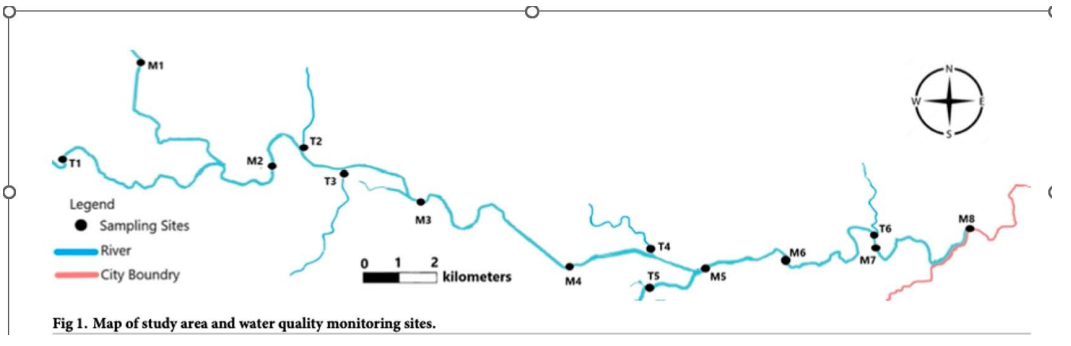

## **Library**

In [4]:
!pip install python-docx

In [5]:
!pip install factor_analyzer

In [6]:
# Library yang dibutuhkan
from google.colab import files
from docx import Document
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from sklearn.decomposition import PCA
from sklearn.decomposition import FactorAnalysis

## **Data**

In [7]:
# Upload file
uploaded = files.upload()

Saving Data kualitas air.docx to Data kualitas air.docx


In [8]:
# Load file
doc = Document("Data kualitas air.docx")

# Mengekstrak semua baris tabel ke list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Mengatur baris pertama jadi header
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Mengganti nama kolom pertama jadi 'Waktu'
df = df.rename(columns={df.columns[0]: 'Waktu'})

In [ ]:
# List variabel dalam data
columns = df.columns.tolist()

# Mengubah list variabel menjadi DataFrame
df_columns = pd.DataFrame(columns, columns=['Variabel'])

# Menampilkan DataFrame yang berisi daftar variabel
df_columns


,Variabel
0,Waktu
1,NO.
2,PH
3,DO
4,COD
5,NH3-N
6,TP
7,CODMn
8,F
9,Oil


In [9]:
# Menampilkan jumlah tiap lokasi pengambilan sampel ("No.")
df['NO.'].value_counts()

,count
NO.,
M1,12
M2,12
T1,12
T2,12
T3,12
M3,12
M4,12
T4,12
T5,12


In [10]:
# Menampilkan waktu pengamatan
df['Waktu']

,Waktu
0,2019.07
1,2019.07
2,2019.07
3,2019.07
4,2019.07
...,...
163,2020.07
164,2020.07
165,2020.07
166,2020.07


In [11]:
df['Waktu'].value_counts()

,count
Waktu,
2019.07,14
2019.08,14
2019.09,14
2019.10,14
2019.11,14
2019.12,14
2020.01,14
2020.03,14
2020.04,14


In [12]:
# Menampilkan 5 baris pertama dari DataFrame
df.head()

,Waktu,NO.,PH,DO,COD,NH3-N,TP,CODMn,F,Oil,...,LAS,Cu,Zn,Cd,As,Hg,CN,VP,S,Se
0,2019.07,M1,7.47,6.9,32,1.48,0.36,7.5,0.75,0.24,...,0.29,0.07,0.05,0.0003,0.0032,0.00026,0.018,0.0012,0.012,0.0006
1,2019.07,M2,7.58,8.5,16,1.12,0.24,4.6,0.76,0.15,...,0.07,0.06,0.03,0.0003,0.0034,0.00025,0.016,0.0006,0.013,0.0006
2,2019.07,T1,7.49,8.2,26,1.24,0.32,7.1,0.81,0.19,...,0.15,0.08,0.05,0.0003,0.0036,0.00026,0.014,0.0012,0.014,0.0008
3,2019.07,T2,7.52,8.3,15,0.88,0.15,5.9,0.39,0.09,...,0.12,0.04,0.04,0.0002,0.0014,0.00012,0.008,0.0007,0.008,0.0004
4,2019.07,T3,7.79,8.2,14,0.82,0.14,6.1,0.38,0.08,...,0.14,0.03,0.06,0.0002,0.0016,0.0003,0.006,0.0005,0.009,0.0003


In [13]:
df

,Waktu,NO.,PH,DO,COD,NH3-N,TP,CODMn,F,Oil,...,LAS,Cu,Zn,Cd,As,Hg,CN,VP,S,Se
0,2019.07,M1,7.47,6.9,32,1.48,0.36,7.5,0.75,0.24,...,0.29,0.07,0.05,0.0003,0.0032,0.00026,0.018,0.0012,0.012,0.0006
1,2019.07,M2,7.58,8.5,16,1.12,0.24,4.6,0.76,0.15,...,0.07,0.06,0.03,0.0003,0.0034,0.00025,0.016,0.0006,0.013,0.0006
2,2019.07,T1,7.49,8.2,26,1.24,0.32,7.1,0.81,0.19,...,0.15,0.08,0.05,0.0003,0.0036,0.00026,0.014,0.0012,0.014,0.0008
3,2019.07,T2,7.52,8.3,15,0.88,0.15,5.9,0.39,0.09,...,0.12,0.04,0.04,0.0002,0.0014,0.00012,0.008,0.0007,0.008,0.0004
4,2019.07,T3,7.79,8.2,14,0.82,0.14,6.1,0.38,0.08,...,0.14,0.03,0.06,0.0002,0.0016,0.0003,0.006,0.0005,0.009,0.0003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2020.07,M5,7.91,8.9,36,1.12,0.26,4.8,0.62,0.08,...,0.23,0.03,0.03,0.0002,0.0028,0.00019,0.018,0.0006,0.009,0.0006
164,2020.07,M6,7.82,8.6,27,0.73,0.15,5.4,0.81,0.19,...,0.28,0.06,0.04,0.0004,0.0024,0.00015,0.017,0.0013,0.007,0.0006
165,2020.07,T6,7.71,8.6,17,0.86,0.21,5.9,0.82,0.18,...,0.26,0.08,0.03,0.0004,0.0032,0.00017,0.008,0.0008,0.009,0.0007
166,2020.07,M7,7.53,7.9,29,0.82,0.19,6.1,0.82,0.19,...,0.24,0.06,0.04,0.0004,0.0027,0.00015,0.017,0.0013,0.008,0.0008


In [14]:
# Menampilkan dimensi data (ukuran DataFrame) dalam bentuk (jumlah baris, jumlah kolom)
df.shape

(168, 21)

Berdasarkan output di atas, diketahui bahwa DataFrame Kualitas Air terdiri dari 168 baris dan 21 kolom.

In [15]:
# Mengecek informasi (tipe) dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Waktu   168 non-null    object
 1   NO.     168 non-null    object
 2   PH      168 non-null    object
 3   DO      168 non-null    object
 4   COD     168 non-null    object
 5   NH3-N   168 non-null    object
 6   TP      168 non-null    object
 7   CODMn   168 non-null    object
 8   F       168 non-null    object
 9   Oil     168 non-null    object
 10  Cr6+    168 non-null    object
 11  LAS     168 non-null    object
 12  Cu      168 non-null    object
 13  Zn      168 non-null    object
 14  Cd      168 non-null    object
 15  As      168 non-null    object
 16  Hg      168 non-null    object
 17  CN      168 non-null    object
 18  VP      168 non-null    object
 19  S       168 non-null    object
 20  Se      168 non-null    object
dtypes: object(21)
memory usage: 27.7+ KB


In [16]:
# Mengubah kolom-kolom yang berisi data numerik menjadi float
#Semua kolom numerik masih bertipe object, ini berarti nilainya disimpan sebagai string (masih text), bukan angka.
df[['PH', 'DO', 'COD', 'NH3-N', 'TP', 'CODMn', 'F', 'Oil', 'Cr6+', 'LAS', 'Cu', 'Zn', 'Cd', 'As', 'Hg', 'CN', 'VP', 'S', 'Se']] = df[['PH', 'DO', 'COD', 'NH3-N', 'TP', 'CODMn', 'F', 'Oil', 'Cr6+', 'LAS', 'Cu', 'Zn', 'Cd', 'As', 'Hg', 'CN', 'VP', 'S', 'Se']].apply(pd.to_numeric, errors='coerce')

In [17]:
# Mengecek ulang informasi (tipe) dataset
#int (bilangan bulat)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Waktu   168 non-null    object 
 1   NO.     168 non-null    object 
 2   PH      168 non-null    float64
 3   DO      168 non-null    float64
 4   COD     168 non-null    int64  
 5   NH3-N   168 non-null    float64
 6   TP      168 non-null    float64
 7   CODMn   168 non-null    float64
 8   F       168 non-null    float64
 9   Oil     168 non-null    float64
 10  Cr6+    168 non-null    float64
 11  LAS     168 non-null    float64
 12  Cu      168 non-null    float64
 13  Zn      168 non-null    float64
 14  Cd      168 non-null    float64
 15  As      168 non-null    float64
 16  Hg      168 non-null    float64
 17  CN      168 non-null    float64
 18  VP      168 non-null    float64
 19  S       168 non-null    float64
 20  Se      168 non-null    float64
dtypes: float64(18), int64(1), object(2)
mem

## **Preprocessing Data**

**Duplicate Data**

In [18]:
# Cek duplicate data
df.duplicated().sum()

np.int64(0)

Tidak terdapat duplikasi pada data.

**Missing Value**

In [19]:
# Cek Missing Value
df.isnull().sum()

,0
Waktu,0
NO.,0
PH,0
DO,0
COD,0
NH3-N,0
TP,0
CODMn,0
F,0
Oil,0


Tidak terdapat missing value pada data.

**Outlier**

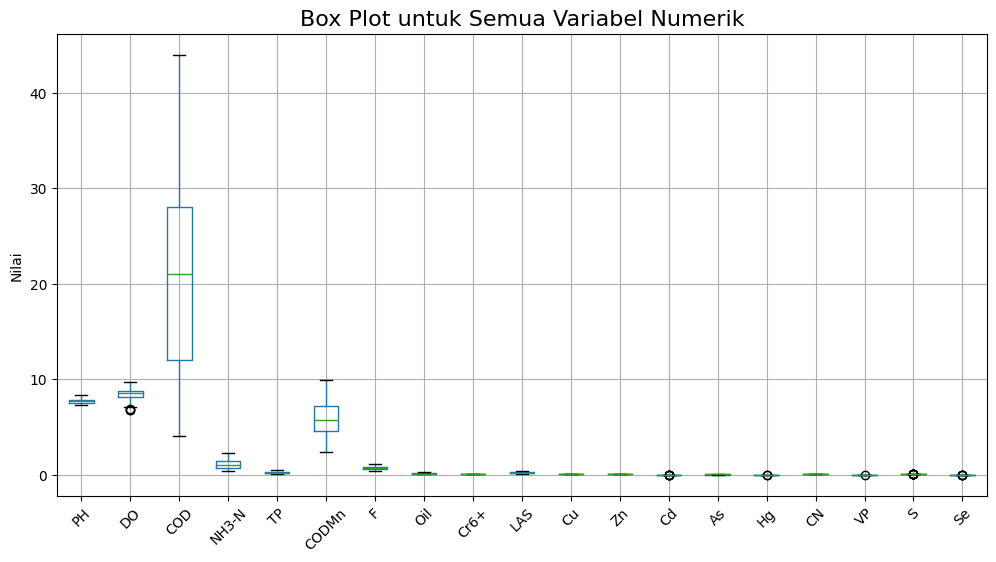

In [20]:
# Memilih kolom numerik dari DataFrame
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Membuat box plot untuk semua kolom numerik
plt.figure(figsize=(12, 6))  # Ukuran plot
df_numeric.boxplot()

# Menambahkan judul dan label sumbu Y
plt.title('Box Plot untuk Semua Variabel Numerik', fontsize=16)
plt.ylabel('Nilai')

# Memutar label sumbu X agar lebih terbaca
plt.xticks(rotation=45)

# Menambahkan grid untuk memudahkan pembacaan
plt.grid(True)

# Menampilkan boxplot untuk mengecek outlier
plt.show()

Berdasarkan box plot di atas, diketahui terdapat outlier pada variabel DO, Cd, Hg, VP, S, dan Se. Outlier tersebut tidak ditangani untuk menjaga keaslian data, karena outlier dapat memberikan informasi penting tentang kondisi ekstrem atau perubahan yang relevan dalam kualitas air.

## **Exploratory Data Analysis (EDA)**

**Statistika Deskriptif**

In [21]:
# Menampilkan statistika deskriptif
statdes = df.describe().transpose()
statdes

,count,mean,std,min,25%,50%,75%,max
PH,168.0,7.649226,0.214766,7.27000,7.47000,7.66500,7.82250,8.3100
DO,168.0,8.398095,0.561424,6.80000,8.10000,8.50000,8.80000,9.7000
COD,168.0,20.577381,10.062974,4.00000,12.00000,21.00000,28.00000,44.0000
NH3-N,168.0,1.057262,0.413162,0.33000,0.73000,0.97000,1.38500,2.2200
TP,168.0,0.196369,0.090298,0.03000,0.13000,0.17500,0.26000,0.4400
CODMn,168.0,5.725595,1.711882,2.40000,4.60000,5.70000,7.20000,9.9000
F,168.0,0.679643,0.157506,0.38000,0.57750,0.66000,0.82000,1.1000
Oil,168.0,0.105417,0.050088,0.02000,0.06000,0.08000,0.16000,0.2400
Cr6+,168.0,0.016292,0.004458,0.00600,0.01400,0.01700,0.02000,0.0260
LAS,168.0,0.201905,0.066746,0.04000,0.15000,0.21000,0.26000,0.3200


In [22]:
def descriptive_table_final(df, parameter_list):
    all_stats = []
    lokasi_set = set()

    for param in parameter_list:
        # Cari kolom yang sesuai: ada '_' dan diakhiri dengan param
        param_cols = [col for col in df.columns if col.endswith('_' + param)]

        temp = pd.DataFrame(index=['Max', 'Min', 'Mean', 'SD'])

        for col in param_cols:
            # Ambil lokasi dari format: M1_pH -> M1
            loc = col.split('_')[0]
            lokasi_set.add(loc)

            temp[loc] = [
                df[col].max(),
                df[col].min(),
                df[col].mean(),
                df[col].std()
            ]

        temp.index = [f"{param} {stat}" for stat in temp.index]
        all_stats.append(temp)

    combined_df = pd.concat(all_stats)
    lokasi_sorted = sorted(lokasi_set)
    combined_df = combined_df[lokasi_sorted]

    return combined_df


In [23]:
# Hitung statistik deskriptif PH per lokasi
statdes_ph_per_lokasi = df.groupby('NO.')['PH'].describe()
statdes_ph_per_lokasi

,count,mean,std,min,25%,50%,75%,max
NO.,,,,,,,,
M1,12.0,7.560000,0.174043,7.37,7.4450,7.465,7.7825,7.81
M2,12.0,7.645833,0.249452,7.31,7.5200,7.595,7.6825,8.31
M3,12.0,7.787500,0.186602,7.32,7.7225,7.810,7.9350,7.98
M4,12.0,7.700000,0.230730,7.31,7.6275,7.770,7.8525,7.98
M5,12.0,7.790833,0.232632,7.28,7.8000,7.900,7.9125,7.96
M6,12.0,7.610833,0.177890,7.32,7.5475,7.660,7.7125,7.82
M7,12.0,7.620833,0.202729,7.38,7.4650,7.525,7.8275,7.89
M8,12.0,7.704167,0.228412,7.41,7.4825,7.665,7.9425,7.97
T1,12.0,7.626667,0.220591,7.40,7.4675,7.490,7.8800,7.99


In [24]:
def build_descriptive_stats(df):
    # Ambil hanya kolom dengan format param_lokasi (misalnya: 'pH_M1')
    valid_cols = [col for col in df.columns if '_' in col]

    # Ambil semua parameter & lokasi dari kolom valid
    parameters = set(col.split('_')[0] for col in valid_cols)
    locations = sorted(set(col.split('_')[1] for col in valid_cols))

    stats = ['Max', 'Min', 'Mean', 'SD']
    output_df = pd.DataFrame()

    for param in sorted(parameters):
        stat_rows = []
        for stat in stats:
            row = []
            for loc in locations:
                col_name = f"{param}_{loc}"
                if col_name in df.columns:
                    series = df[col_name]
                    if stat == 'Max':
                        row.append(series.max())
                    elif stat == 'Min':
                        row.append(series.min())
                    elif stat == 'Mean':
                        row.append(series.mean())
                    elif stat == 'SD':
                        row.append(series.std())
                else:
                    row.append(None)
            stat_rows.append(row)

        # Buat DataFrame sementara per parameter
        temp_df = pd.DataFrame(stat_rows, columns=locations)
        temp_df.index = [f"{param} {stat}" for stat in stats]

        # Gabungkan ke hasil akhir
        output_df = pd.concat([output_df, temp_df])

    return output_df

descriptive_table = build_descriptive_stats(df)
display(descriptive_table)

""


In [25]:
print(df.columns)

Index(['Waktu', 'NO.', 'PH', 'DO', 'COD', 'NH3-N', 'TP', 'CODMn', 'F', 'Oil',
       'Cr6+', 'LAS', 'Cu', 'Zn', 'Cd', 'As', 'Hg', 'CN', 'VP', 'S', 'Se'],
      dtype='object')


In [26]:
# Ganti nama kolom agar lebih konsisten (jika diperlukan)
df.rename(columns={'NO.': 'Lokasi'}, inplace=True)

# Ubah data ke format panjang (long format)
df_long = df.melt(id_vars=['Waktu', 'Lokasi'],
                  var_name='Parameter',
                  value_name='Nilai')

# Menampilkan 5 baris pertama hasil reshape
df_long.head()

,Waktu,Lokasi,Parameter,Nilai
0,2019.07,M1,PH,7.47
1,2019.07,M2,PH,7.58
2,2019.07,T1,PH,7.49
3,2019.07,T2,PH,7.52
4,2019.07,T3,PH,7.79


**Distribusi Tiap Variabel Pada Data**

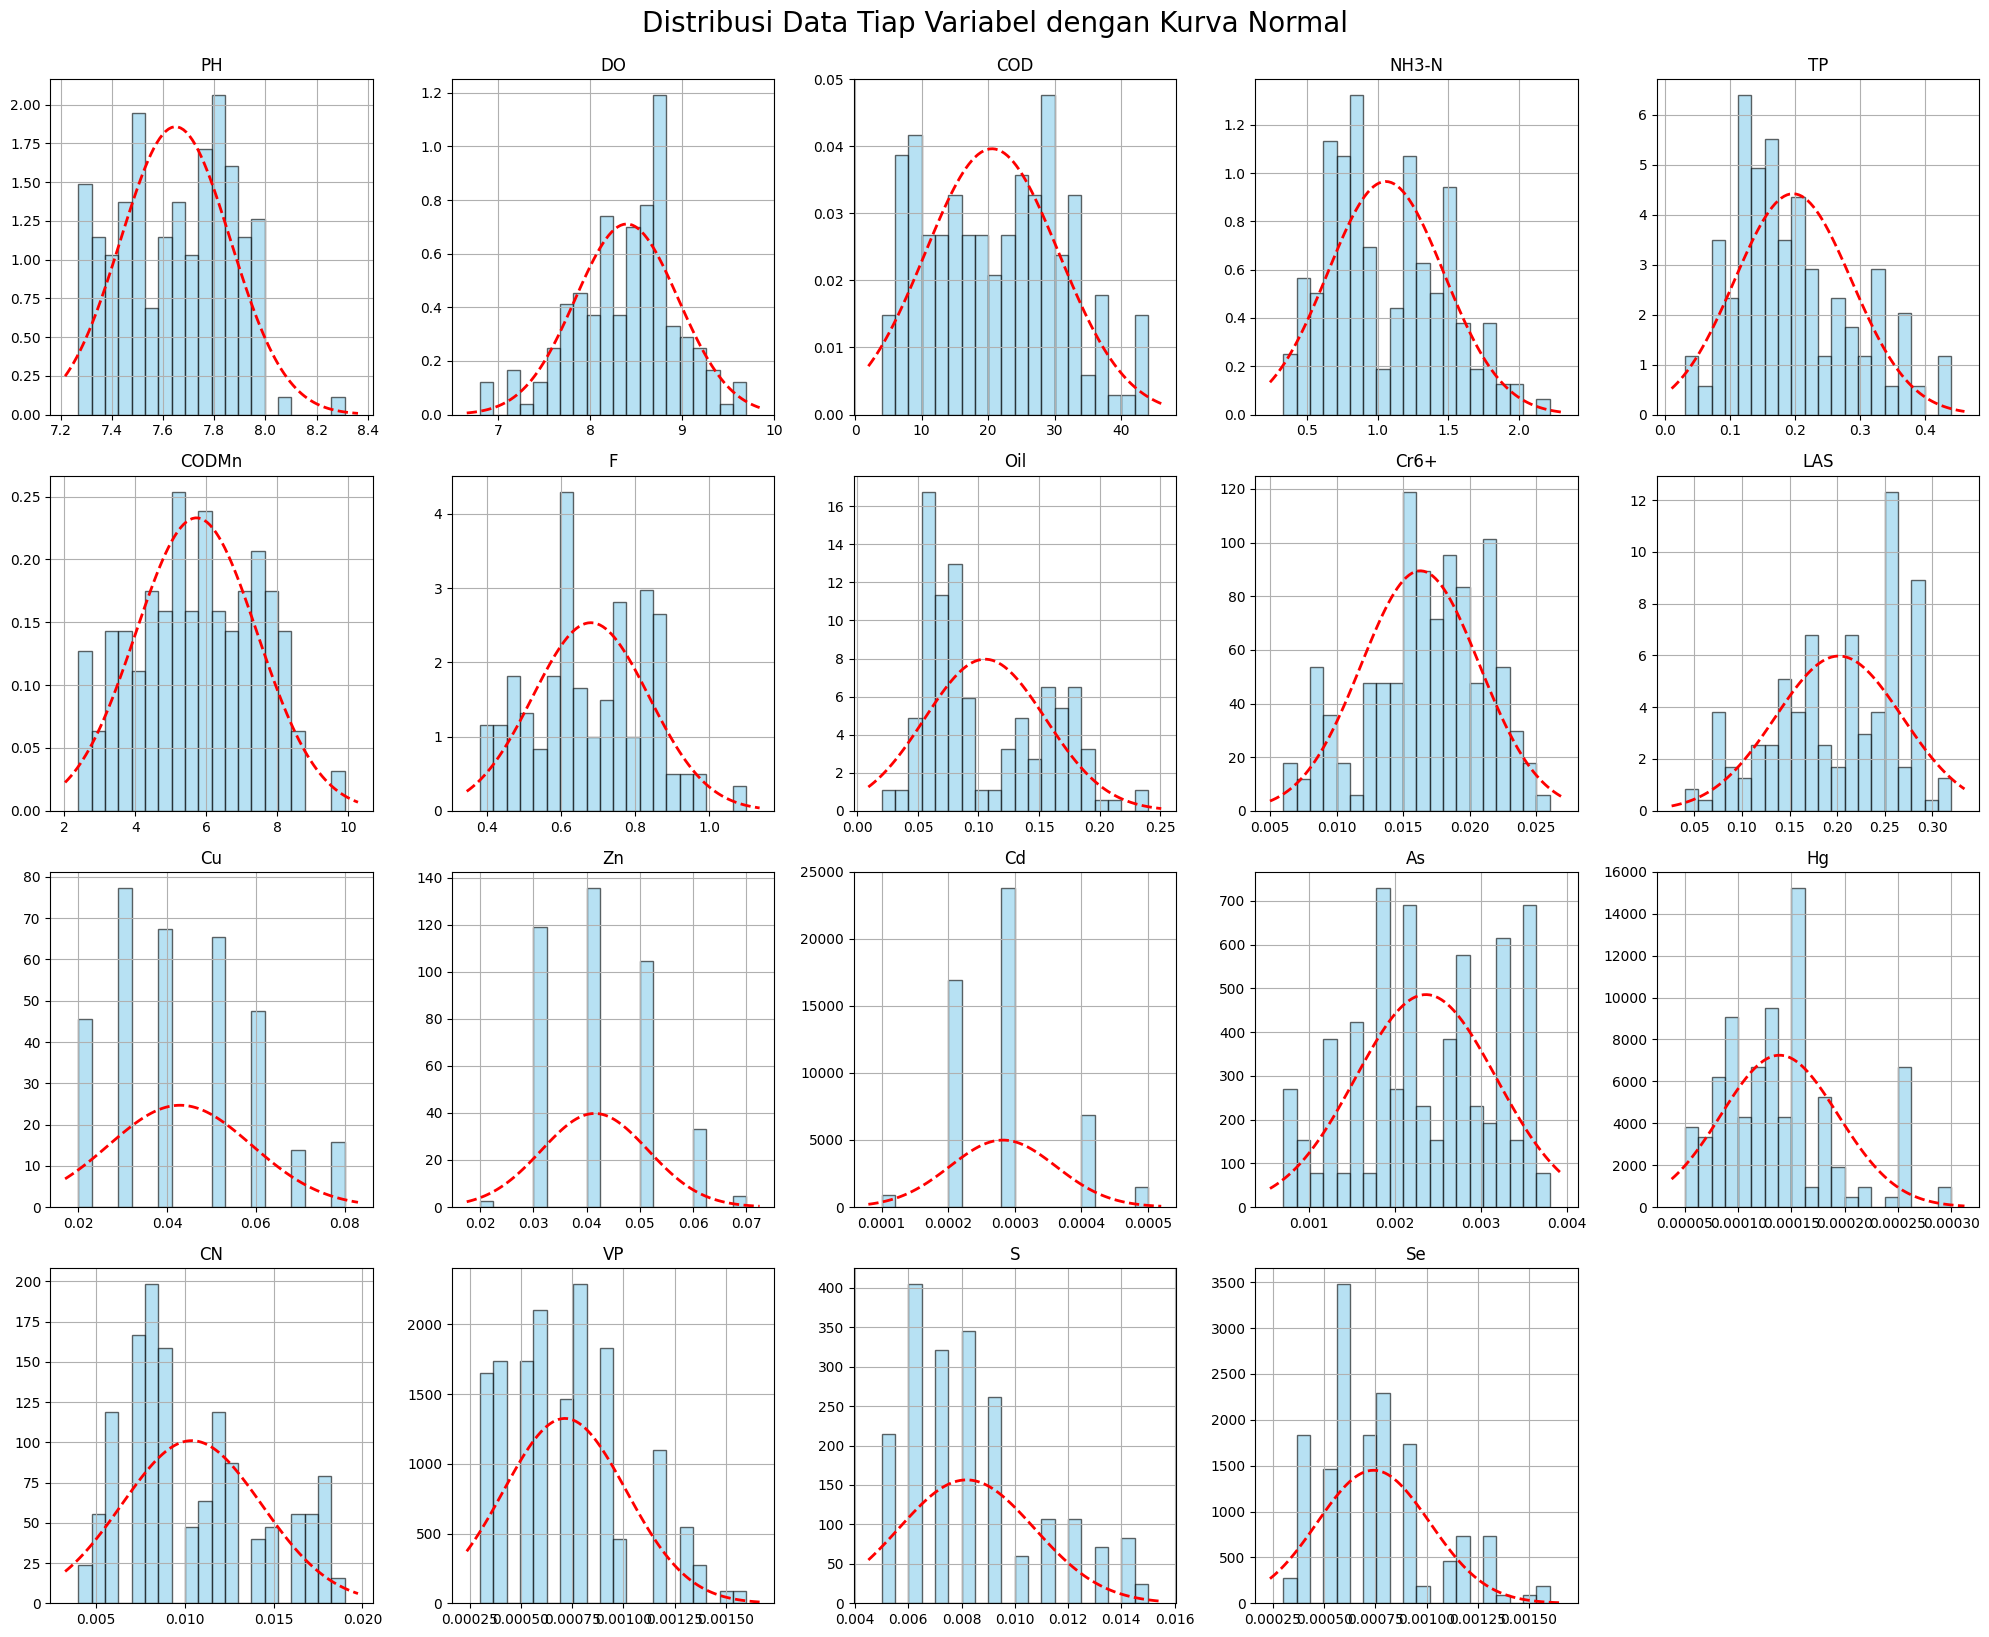

In [27]:
# Plot untuk semua kolom
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 16))  # 4 baris x 5 kolom
axes = axes.flatten()

# Plot histogram + distribusi normal
for i, col in enumerate(df_numeric.columns):
    ax = axes[i]
    data = df_numeric[col].dropna()

    ax.hist(data, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')

    mean, std = data.mean(), data.std()
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, std)
    ax.plot(x, p, 'r--', linewidth=2)

    ax.set_title(col)
    ax.grid(True)

# Menghilangkan axes yang tidak terpakai
for j in range(len(df_numeric.columns), len(axes)):
    fig.delaxes(axes[j])

# Menampilkan Plot
plt.tight_layout()
plt.suptitle('Distribusi Data Tiap Variabel dengan Kurva Normal', fontsize=20, y=1.02)
plt.show()

**Korelasi Antar Variabel**

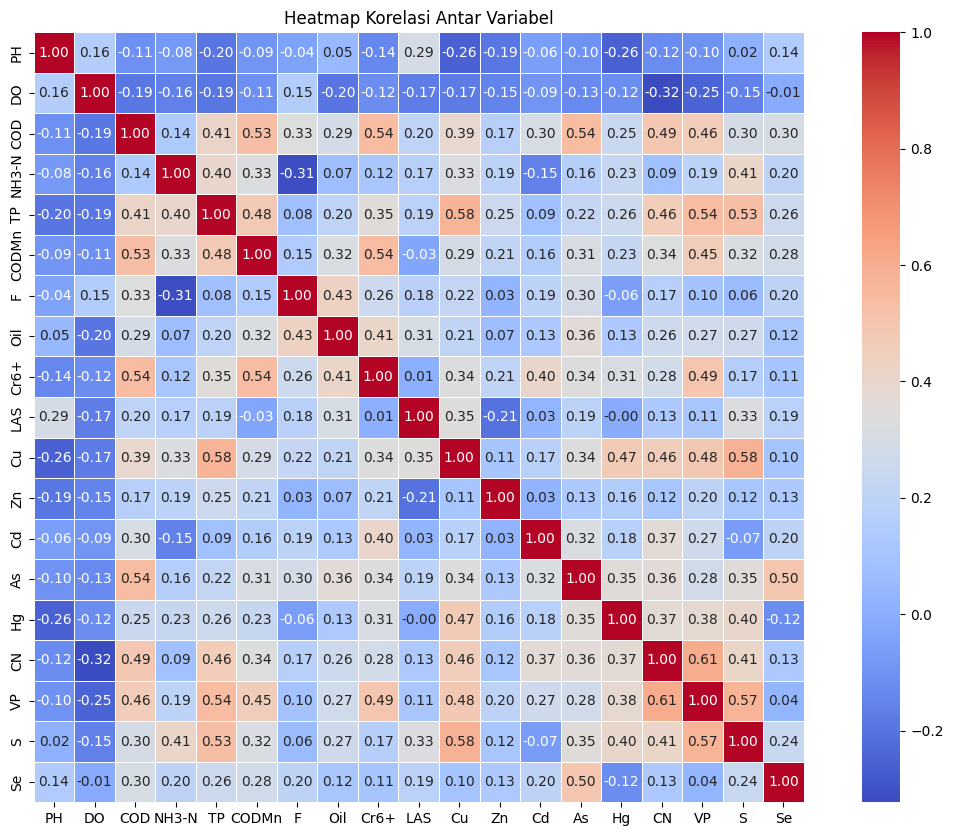

In [28]:
# Menghitung matriks korelasi variabel numerik
corr_matrix = df_numeric.corr()

# Membuat heatmap untuk visualisasi korelasi
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            linecolor='white',
            square=True)

# Menambahkan judul
plt.title('Heatmap Korelasi Antar Variabel', fontsize=12)

# Menampilkan heatmap
plt.show()

## **Analisis Multivariat**

### **Analisis Kluster**

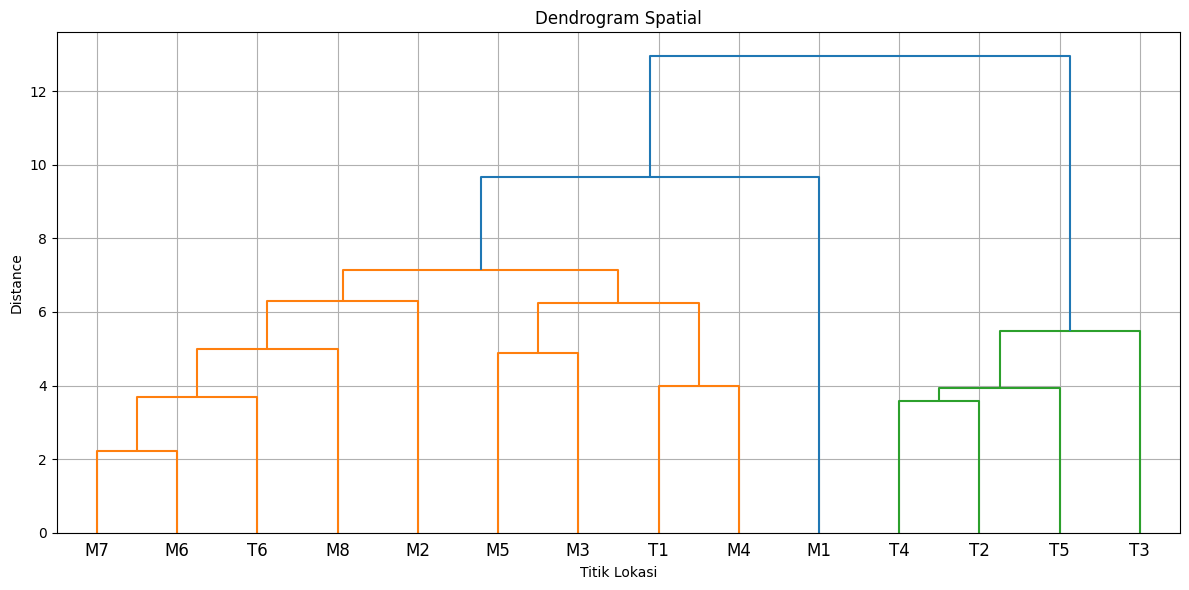

In [29]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from docx import Document

# 2. Load data dari file Word
doc = Document("/content/Data kualitas air.docx")

# Ekstrak semua tabel ke list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Atur baris pertama jadi header
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Ganti nama kolom pertama jadi 'Waktu'
df = df.rename(columns={df.columns[0]: 'Waktu'})

# 3. Filter hanya kolom yang diperlukan (hapus kolom 'Waktu' karena kita akan fokus pada lokasi)
data = df.drop(columns=['Waktu'])  # Buang kolom 'Waktu' untuk fokus pada lokasi (NO.)

# 3.5 Konversi kolom angka menjadi numerik
data.iloc[:, 1:] = data.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# 4. Group by lokasi (NO.) dan hitung rata-rata untuk setiap lokasi
grouped_data_location = data.groupby('NO.').mean()

# 5. Standarisasi data
scaler = StandardScaler()
scaled_data_location = scaler.fit_transform(grouped_data_location)

# 6. Hierarchical clustering linkage (spatial similarity)
linked_location = linkage(scaled_data_location, method='ward')

# 7. Plot dendrogram untuk spatial similarity (berdasarkan NO.)
plt.figure(figsize=(12, 6))
dendrogram(linked_location,
           labels=grouped_data_location.index.tolist(),  # Label berdasarkan NO. (titik lokasi)
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram Spatial')
plt.xlabel('Titik Lokasi')
plt.ylabel('Distance')
plt.grid(True)
plt.tight_layout()
plt.show()


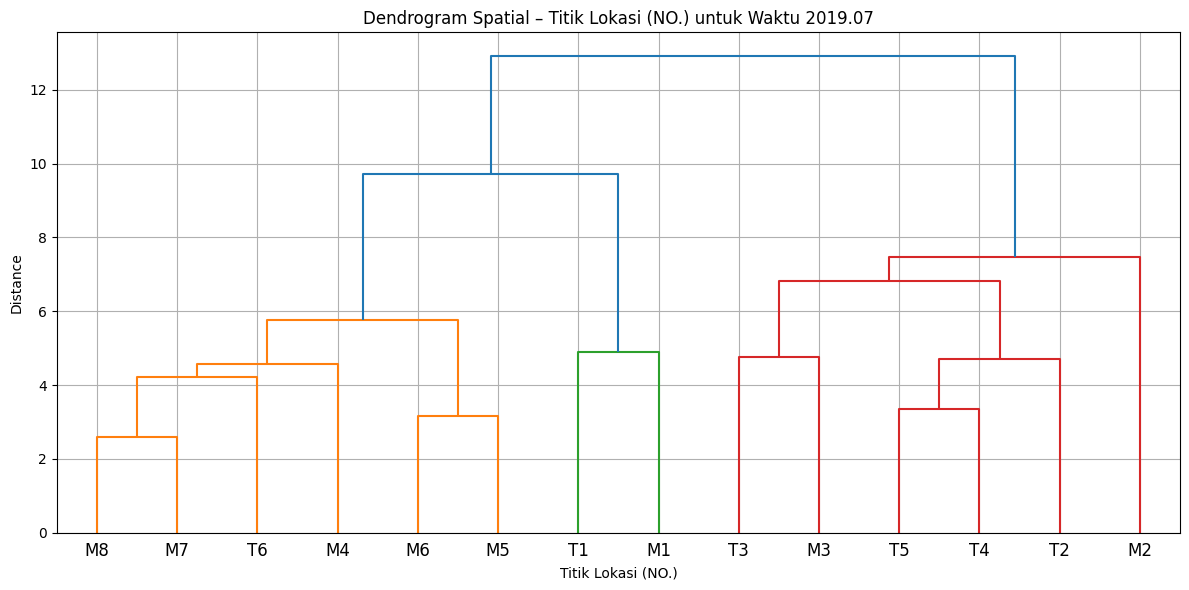

In [30]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from docx import Document

# 2. Load data dari file Word
doc = Document("/content/Data kualitas air.docx")

# Ekstrak semua tabel ke list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Konversi ke DataFrame
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Ganti nama kolom pertama menjadi 'Waktu'
df = df.rename(columns={df.columns[0]: 'Waktu'})

# 3. Filter hanya data untuk waktu tertentu (misalnya: '2019.07')
df_filtered = df[df['Waktu'] == '2019.07'].copy()

# 4. Konversi kolom numerik ke tipe numerik (kecuali kolom 'NO.')
for col in df_filtered.columns:
    if col not in ['Waktu', 'NO.']:
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# 5. Group by lokasi (NO.) dan hitung rata-rata untuk waktu 2019.07
grouped_data_location = df_filtered.groupby('NO.').mean(numeric_only=True)

# 6. Standarisasi data
scaler = StandardScaler()
scaled_data_location = scaler.fit_transform(grouped_data_location)

# 7. Hierarchical clustering linkage
linked_location = linkage(scaled_data_location, method='ward')

# 8. Plot dendrogram spatial berdasarkan NO. untuk waktu 2019.07
plt.figure(figsize=(12, 6))
dendrogram(
    linked_location,
    labels=grouped_data_location.index.tolist(),
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrogram Spatial – Titik Lokasi (NO.) untuk Waktu 2019.07')
plt.xlabel('Titik Lokasi (NO.)')
plt.ylabel('Distance')
plt.grid(True)
plt.tight_layout()
plt.show()


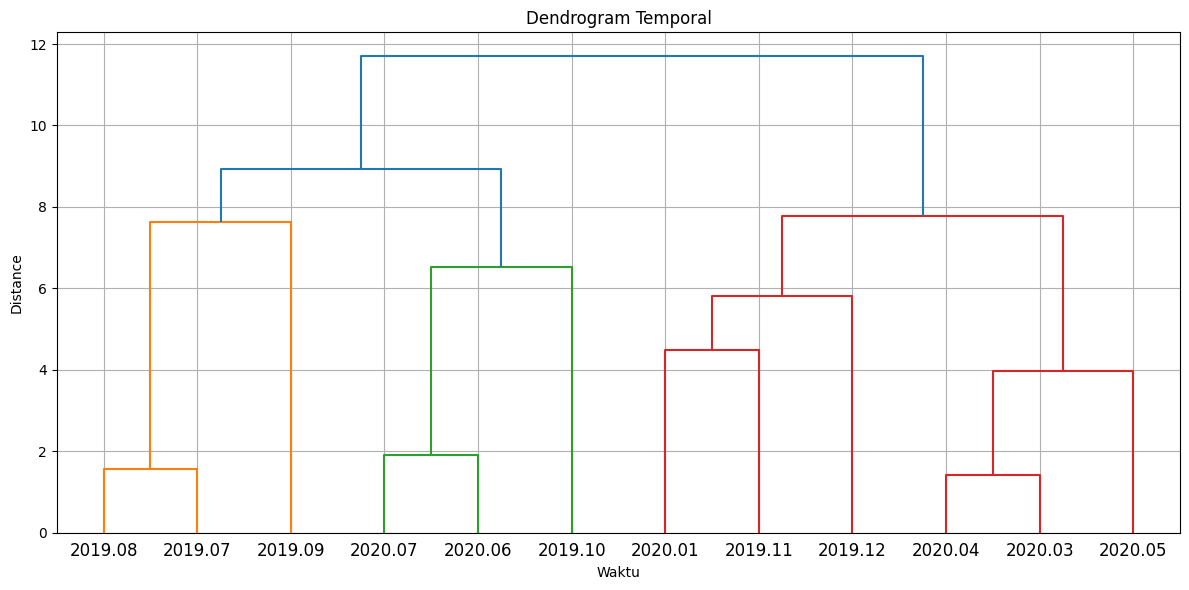

In [31]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from docx import Document

# 2. Load data dari file Word
doc = Document("/content/Data kualitas air.docx")

# Ekstrak semua tabel ke list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Atur baris pertama jadi header
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Ganti nama kolom pertama jadi 'Waktu'
df = df.rename(columns={df.columns[0]: 'Waktu'})

# 3. Filter hanya kolom yang diperlukan
data = df.drop(columns=['NO.'])  # Buang kolom 'NO.' untuk temporal analysis

# 3.5 Konversi kolom angka menjadi numerik
data.iloc[:, 1:] = data.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# 4. Group by waktu
grouped_data_temporal = data.groupby('Waktu').mean()

# 5. Standarisasi data
scaler = StandardScaler()
scaled_data_temporal = scaler.fit_transform(grouped_data_temporal)

# 6. Hierarchical clustering linkage (temporal similarity)
linked_temporal = linkage(scaled_data_temporal, method='ward')

# 7. Plot dendrogram untuk temporal similarity
plt.figure(figsize=(12, 6))
dendrogram(linked_temporal,
           labels=grouped_data_temporal.index.tolist(),  # Label berdasarkan waktu
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram Temporal')
plt.xlabel('Waktu')
plt.ylabel('Distance')
plt.grid(True)
plt.tight_layout()
plt.show()


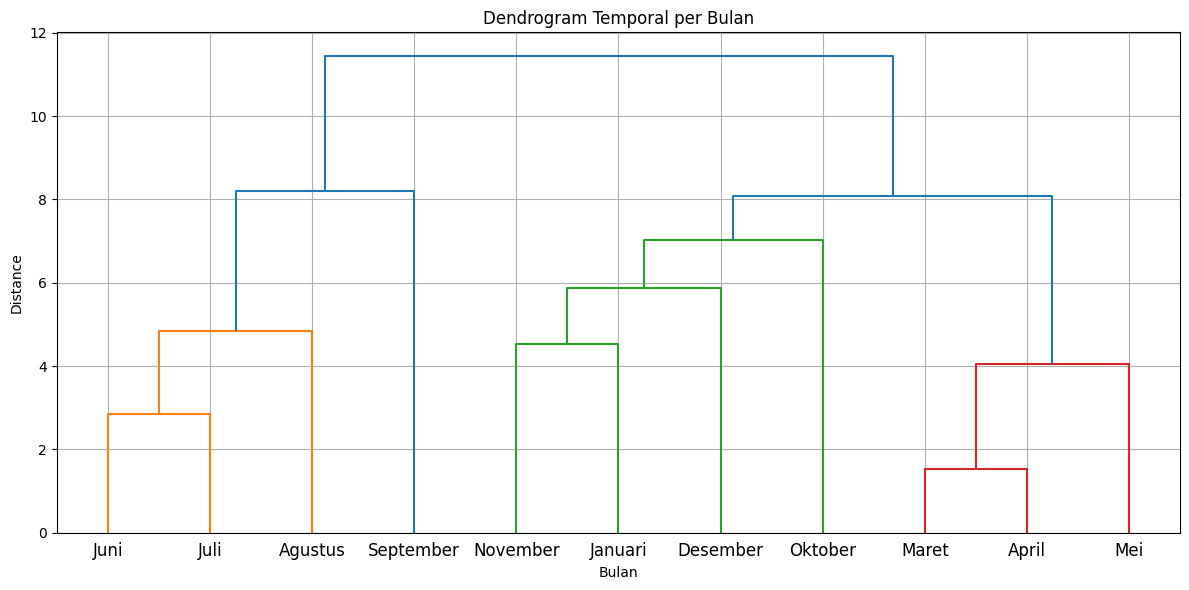

In [32]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from docx import Document

# 2. Load data dari file Word
doc = Document("/content/Data kualitas air.docx")

# Ekstrak semua tabel ke list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Atur baris pertama jadi header
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Ganti nama kolom pertama jadi 'Waktu'
df = df.rename(columns={df.columns[0]: 'Waktu'})

# 3. Ekstrak bulan dari kolom 'Waktu'
df['Bulan'] = df['Waktu'].str[-2:]

# 4. Drop kolom yang tidak dianalisis
data = df.drop(columns=['NO.', 'Waktu'])

# 5. Pisahkan kolom 'Bulan' untuk digunakan sebagai gruping, dan ubah sisanya jadi numerik
bulan_col = data['Bulan']
data_numerik = data.drop(columns=['Bulan']).apply(pd.to_numeric, errors='coerce')

# Mapping angka ke nama bulan
bulan_mapping = {
    '01': 'Januari', '02': 'Februari', '03': 'Maret', '04': 'April',
    '05': 'Mei', '06': 'Juni', '07': 'Juli', '08': 'Agustus',
    '09': 'September', '10': 'Oktober', '11': 'November', '12': 'Desember'
}
data_numerik['Bulan'] = bulan_col.map(bulan_mapping)


# 6. Group by Bulan dan hitung rata-rata
grouped_data_by_month = data_numerik.groupby('Bulan').mean()

# 7. Standarisasi data
scaler = StandardScaler()
scaled_data_month = scaler.fit_transform(grouped_data_by_month)

# 8. Clustering linkage
linked_month = linkage(scaled_data_month, method='ward')

# 9. Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked_month,
           labels=grouped_data_by_month.index.tolist(),
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram Temporal per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Distance')
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
# Convert scaled data to DataFrame to display
scaled_data_temporal_df = pd.DataFrame(scaled_data_temporal, columns=grouped_data_temporal.columns, index=grouped_data_temporal.index)

# Tampilkan tabel rata-rata yang sudah distandarisasi
scaled_data_temporal_df

,PH,DO,COD,NH3-N,TP,CODMn,F,Oil,Cr6+,LAS,Cu,Zn,Cd,As,Hg,CN,VP,S,Se
Waktu,,,,,,,,,,,,,,,,,,,
2019.07,-1.475331,-1.165627,1.043857,-0.549599,1.828808,1.090958,-0.554093,-1.103931,2.257696,-1.064094,1.153426,0.688796,1.466439,0.291651,1.733455,0.832743,0.650791,-0.149638,-0.912811
2019.08,-1.224247,0.007631,1.489388,-0.543943,1.704996,1.090958,-0.314485,-1.625473,1.711951,-0.731865,1.153426,0.509110,1.466439,0.291651,1.582172,0.832743,0.650791,-0.239420,-0.912811
2019.09,-1.895512,1.810442,0.289881,1.102027,0.466875,1.150628,2.081594,0.147770,0.347588,-2.104113,-0.338430,2.845026,-0.488813,1.197009,0.371905,0.134708,-0.433861,-0.239420,1.169940
2019.10,0.830541,-0.793619,-0.823947,-0.888975,0.374016,1.007421,0.284534,1.399471,-0.626957,-1.280764,-1.415882,-0.029948,-1.140563,-1.397449,-0.970735,1.089914,1.807754,1.017535,-0.912811
2019.11,-0.143049,0.001908,-1.389429,-0.934225,0.033532,-0.603657,-1.272917,1.086546,-0.665939,0.365933,-0.338430,-0.569005,-0.814688,-2.451448,-0.460154,-0.783758,-1.120807,-0.957680,-1.105658
2019.12,1.266094,1.896291,-0.703996,-1.019068,-0.740293,1.413174,2.081594,-0.686697,-1.055757,-0.038519,-1.167240,-1.108063,-1.792314,-0.897475,-1.103108,-1.738964,-1.301583,-1.765723,0.822815
2020.01,0.687064,-0.164065,-2.023454,-1.086943,-1.421260,-1.355493,-0.254583,-0.373772,-1.055757,0.640382,-1.250120,-0.209633,-0.488813,0.264626,-0.895093,-1.151145,-0.976187,-1.227028,0.899954
2020.03,0.897155,0.236559,0.478375,1.531902,-1.049824,-0.878137,-0.524142,-1.208239,-0.626957,0.625937,-0.504192,-0.209633,-0.162938,0.588933,-0.781631,-0.636804,-0.542326,0.029928,1.324218
2020.04,0.989390,-0.392994,0.546918,1.826027,-0.802199,-0.627525,-0.584044,-0.165155,-0.432048,0.611493,-0.338430,-0.029948,-0.162938,0.521369,-0.724900,-0.489849,-0.542326,-0.329203,1.555635


### **Analisis Diskriminan**

In [34]:
!pip install pingouin


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.4 MB/s eta 0:00:00


In [35]:
import pandas as pd
import pingouin as pg

# 1. Hapus kolom 'Waktu' dan 'NO.'
df_clean = df.drop(columns=['Waktu', 'NO.'])

# 2. Konversi ke numerik
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# 3. Uji normalitas multivariat
H, pval, normal = pg.multivariate_normality(df_clean)

# 4. Tampilkan hasil dengan format rapi
print("=== Uji Normalitas Multivariat (Royston's Test) ===")
print(f"Statistik H      : {H:.4f}")
print(f"p-value          : {pval:.4f}")
print(f"Hasil Interpretasi: {'Data berdistribusi normal' if normal else 'Data TIDAK berdistribusi normal'}")


=== Uji Normalitas Multivariat (Royston's Test) ===
Statistik H      : 1.1191
p-value          : 0.0000
Hasil Interpretasi: Data TIDAK berdistribusi normal


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Waktu   168 non-null    object
 1   NO.     168 non-null    object
 2   PH      168 non-null    object
 3   DO      168 non-null    object
 4   COD     168 non-null    object
 5   NH3-N   168 non-null    object
 6   TP      168 non-null    object
 7   CODMn   168 non-null    object
 8   F       168 non-null    object
 9   Oil     168 non-null    object
 10  Cr6+    168 non-null    object
 11  LAS     168 non-null    object
 12  Cu      168 non-null    object
 13  Zn      168 non-null    object
 14  Cd      168 non-null    object
 15  As      168 non-null    object
 16  Hg      168 non-null    object
 17  CN      168 non-null    object
 18  VP      168 non-null    object
 19  S       168 non-null    object
 20  Se      168 non-null    object
 21  Bulan   168 non-null    object
dtypes: object(22)
memory usage

In [37]:
!!pip install factor_analyzer


['Requirement already satisfied: factor_analyzer in /usr/local/lib/python3.11/dist-packages (0.5.1)',
 'Requirement already satisfied: pandas in /usr/local/lib/python3.11/dist-packages (from factor_analyzer) (2.2.2)',
 'Requirement already satisfied: scipy in /usr/local/lib/python3.11/dist-packages (from factor_analyzer) (1.15.2)',
 'Requirement already satisfied: numpy in /usr/local/lib/python3.11/dist-packages (from factor_analyzer) (2.0.2)',
 'Requirement already satisfied: scikit-learn in /usr/local/lib/python3.11/dist-packages (from factor_analyzer) (1.6.1)',
 'Requirement already satisfied: python-dateutil>=2.8.2 in /usr/local/lib/python3.11/dist-packages (from pandas->factor_analyzer) (2.9.0.post0)',
 'Requirement already satisfied: pytz>=2020.1 in /usr/local/lib/python3.11/dist-packages (from pandas->factor_analyzer) (2025.2)',
 'Requirement already satisfied: tzdata>=2022.7 in /usr/local/lib/python3.11/dist-packages (from pandas->factor_analyzer) (2025.2)',
 'Requirement alrea

Uji Bartlett sangat sensitif terhadap pelanggaran normalitas. Jika data tidak normal, lebih disarankan menggunakan uji Levene atau uji Brown-Forsythe sebagai alternatif yang lebih robust.

In [38]:
# 1. Import library
import pandas as pd
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

# 2. Bersihkan data
df_clean = df.drop(columns=['Waktu', 'NO.'])
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')
df_clean = df_clean.dropna()

# 3. Hitung dan tampilkan matriks kovarians
cov_matrix = df_clean.cov()

# 4. Hitung uji Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(df_clean)

# 5. Tampilkan hasil uji Bartlett
print("\nHasil Uji Bartlett:")
print(f"Chi-Square: {chi_square_value}")
print(f"P-Value: {p_value}")

# 6. Interpretasi
alpha = 0.05
if p_value < alpha:
    print("Tolak H0: Matriks kovarians berbeda dari identitas (Data cocok untuk analisis faktor)")
else:
    print("Gagal tolak H0: Tidak ada perbedaan signifikan (Matriks kovarians homogen, asumsi homoskedastisitas terpenuhi)")



Hasil Uji Bartlett:
Chi-Square: 1424.6743581607507
P-Value: 6.506081278173296e-188
Tolak H0: Matriks kovarians berbeda dari identitas (Data cocok untuk analisis faktor)


In [39]:
print("Matriks Kovarians:")
cov_matrix

Matriks Kovarians:


,PH,DO,COD,NH3-N,TP,CODMn,F,Oil,Cr6+,LAS,Cu,Zn,Cd,As,Hg,CN,VP,S,Se,Bulan
PH,0.046125,0.018982,-0.235479,-0.006999,-3.813605e-03,-0.033938,-1.454170e-03,5.760729e-04,-1.346831e-04,4.200884e-03,-9.031188e-04,-4.173581e-04,-1.007913e-06,-1.709691e-05,-3.048232e-06,-1.044939e-04,-6.773311e-06,9.309952e-06,8.456658e-06,-0.081502
DO,0.018982,0.315196,-1.047995,-0.037338,-9.626119e-03,-0.105640,1.366159e-02,-5.598004e-03,-2.934531e-04,-6.308925e-03,-1.584830e-03,-8.521243e-04,-4.153978e-06,-5.951354e-05,-3.684916e-06,-7.165155e-04,-4.208041e-05,-2.214314e-04,-1.323638e-06,0.323912
COD,-0.235479,-1.047995,101.263437,0.585063,3.742647e-01,9.203097,5.303871e-01,1.455963e-01,2.425574e-02,1.340433e-01,6.411427e-02,1.736456e-02,2.439050e-04,4.434542e-03,1.375777e-04,1.947334e-02,1.403678e-03,7.679783e-03,8.399629e-04,-1.035429
NH3-N,-0.006999,-0.037338,0.585063,0.170703,1.496724e-02,0.235076,-2.047224e-02,1.473004e-03,2.143962e-04,4.654348e-03,2.185878e-03,7.809096e-04,-5.115056e-06,5.535721e-05,5.231451e-06,1.465583e-04,2.365013e-05,4.305247e-04,2.240490e-05,-0.171966
TP,-0.003814,-0.009626,0.374265,0.014967,8.153803e-03,0.074111,1.177139e-03,9.036178e-04,1.409456e-04,1.121329e-03,8.405938e-04,2.308027e-04,6.174080e-07,1.636930e-05,1.285472e-06,1.631280e-04,1.475278e-05,1.225520e-04,6.351440e-06,0.032750
CODMn,-0.033938,-0.105640,9.203097,0.235076,7.411146e-02,2.930539,3.924872e-02,2.736951e-02,4.139795e-03,-3.803536e-03,8.116517e-03,3.594882e-03,2.141788e-05,4.408472e-04,2.213844e-05,2.269832e-03,2.331651e-04,1.393299e-03,1.324907e-04,1.378194
F,-0.001454,0.013662,0.530387,-0.020472,1.177139e-03,0.039249,2.480825e-02,3.415120e-03,1.860329e-04,1.907870e-03,5.627246e-04,4.965783e-05,2.418734e-06,3.842280e-05,-4.830624e-07,1.074423e-04,4.723695e-06,2.455945e-05,8.571429e-06,0.031707
Oil,0.000576,-0.005598,0.145596,0.001473,9.036178e-04,0.027370,3.415120e-03,2.508807e-03,9.068613e-05,1.024351e-03,1.733283e-04,3.527944e-05,5.224551e-07,1.479815e-05,3.597804e-07,5.175649e-05,4.143713e-06,3.447106e-05,1.653693e-06,0.005724
Cr6+,-0.000135,-0.000293,0.024256,0.000214,1.409456e-04,0.004140,1.860329e-04,9.068613e-05,1.987250e-05,1.896208e-06,2.465319e-05,9.186627e-06,1.441617e-07,1.254217e-06,7.687625e-08,4.972056e-06,6.628743e-07,1.878244e-06,1.336327e-07,0.000492
LAS,0.004201,-0.006309,0.134043,0.004654,1.121329e-03,-0.003804,1.907870e-03,1.024351e-03,1.896208e-06,4.455033e-03,3.728543e-04,-1.382948e-04,1.719418e-07,1.061534e-05,-1.448532e-08,3.388081e-05,2.254063e-06,5.556316e-05,3.431423e-06,-0.077206


In [40]:
# 1. Import library
import pandas as pd
from scipy.stats import levene

# 2. Persiapkan data (pastikan df sudah ada)
# Drop kolom non-numerik
df_clean = df.drop(columns=['Waktu'])
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')
df_clean['NO.'] = df['NO.']
df_clean = df_clean.dropna()

# 3. Lakukan uji Brown-Forsythe untuk setiap variabel terhadap grup 'NO.'
results = []
group_col = 'NO.'

for col in df_clean.columns:
    if col == group_col:
        continue

    # Ambil nilai dari setiap grup
    groups = [group[col].values for name, group in df_clean.groupby(group_col)]

    # Uji Brown-Forsythe (menggunakan median sebagai pusat)
    stat, p = levene(*groups, center='median')

    results.append({'Variabel': col, 'Statistik': stat, 'p-value': p})

# 4. Tampilkan hasil
result_df = pd.DataFrame(results)
print("\nHasil Uji Brown-Forsythe untuk Homogenitas Varians:")
print(result_df)

# 5. Interpretasi singkat
alpha = 0.05
result_df['Interpretasi'] = result_df['p-value'].apply(lambda p: 'Tolak H0 (varians berbeda)' if p < alpha else 'Gagal tolak H0 (varians homogen)')
print("\nInterpretasi:")
print(result_df[['Variabel', 'p-value', 'Interpretasi']])



Hasil Uji Brown-Forsythe untuk Homogenitas Varians:
   Variabel  Statistik       p-value
0        PH   0.375972  9.755931e-01
1        DO   2.414716  5.436403e-03
2       COD   1.995381  2.443438e-02
3     NH3-N   1.105792  3.580728e-01
4        TP   0.966204  4.871545e-01
5     CODMn   3.204437  2.729530e-04
6         F   1.991014  2.480696e-02
7       Oil   3.270241  2.116842e-04
8      Cr6+   2.218822  1.109201e-02
9       LAS   0.895901  5.587964e-01
10       Cu   0.705989  7.554268e-01
11       Zn   0.860636  5.956602e-01
12       Cd   2.312124  7.914293e-03
13       As   0.969923  4.834617e-01
14       Hg   2.498794  3.984121e-03
15       CN  15.388278  6.862569e-22
16       VP   2.331349  7.378910e-03
17        S   3.540776  7.416696e-05
18       Se   4.682788  8.801495e-07
19    Bulan   0.000000  1.000000e+00

Interpretasi:
   Variabel       p-value                      Interpretasi
0        PH  9.755931e-01  Gagal tolak H0 (varians homogen)
1        DO  5.436403e-03        To

#### **Analisis Diskriminan Spasial**

Cross-validation accuracy: 0.65


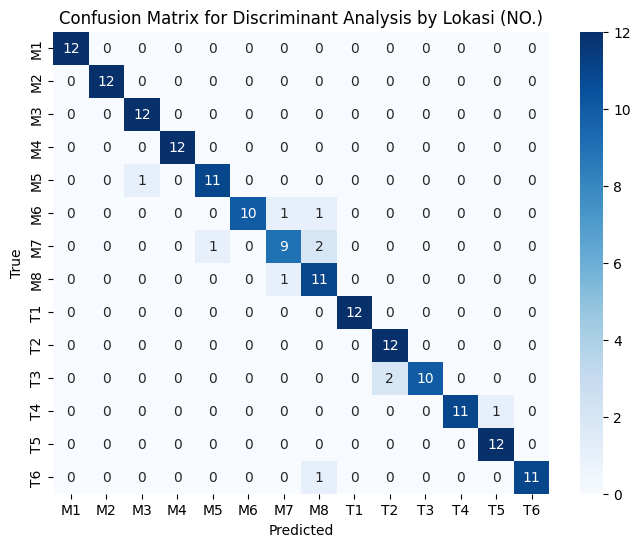

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

   Lokasi  Accuracy  Precision    Recall  F1-Score
0      M1  1.000000        1.0  1.000000  1.000000
1      M2  1.000000        1.0  1.000000  1.000000
2      T1  1.000000        1.0  1.000000  1.000000
3      T2  1.000000        1.0  1.000000  1.000000
4      T3  0.833333        1.0  0.833333  0.909091
5      M3  1.000000        1.0  1.000000  1.000000
6      M4  1.000000        1.0  1.000000  1.000000
7      T4  0.916667        1.0  0.916667  0.956522
8      T5  1.000000        1.0  1.000000  1.000000
9      M5  0.916667        1.0  0.916667  0.956522
10     M6  0.833333        1.0  0.833333  0.909091
11     T6  0.916667        1.0  0.916667  0.956522
12     M7  0.750000        1.0  0.750000  0.857143
13     M8  0.916667        1.0  0.916667  0.956522


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

In [41]:
# 1. Load data dari file Word
from docx import Document
import pandas as pd

# Baca dokumen Word
doc = Document("/content/Data kualitas air.docx")

# Ekstrak semua tabel ke dalam list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Atur baris pertama menjadi header
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Ganti nama kolom pertama menjadi 'Waktu'
df = df.rename(columns={df.columns[0]: 'Waktu'})

# 2. Tentukan fitur dan target
X = df.drop(columns=['Waktu', 'NO.'])  # Fitur (hapus kolom non-numerik)
X = X.apply(pd.to_numeric, errors='coerce')  # Ubah fitur jadi numerik
y = df['NO.']  # Target: lokasi


# 4. Standarisasi data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Membangun model LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()

# 6. Latih model
lda.fit(X_scaled, y)

# 7. Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lda, X_scaled, y, cv=5)
print(f"Cross-validation accuracy: {cv_scores.mean():.2f}")

# 8. Confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = lda.predict(X_scaled)
conf_matrix = confusion_matrix(y, y_pred)

# 9. Visualisasi confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=lda.classes_, yticklabels=lda.classes_)
plt.title('Confusion Matrix for Discriminant Analysis by Lokasi (NO.)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 10. Evaluasi per lokasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

location_evaluation = []

for location in df['NO.'].unique():
    location_data = df[df['NO.'] == location]
    X_location = location_data.drop(columns=['Waktu', 'NO.'])
    X_location = X_location.apply(pd.to_numeric, errors='coerce')
    y_location = location_data['NO.']

    X_location_scaled = scaler.transform(X_location)
    y_pred_location = lda.predict(X_location_scaled)

    location_evaluation.append({
        'Lokasi': location,
        'Accuracy': accuracy_score(y_location, y_pred_location),
        'Precision': precision_score(y_location, y_pred_location, average='weighted', labels=lda.classes_),
        'Recall': recall_score(y_location, y_pred_location, average='weighted', labels=lda.classes_),
        'F1-Score': f1_score(y_location, y_pred_location, average='weighted', labels=lda.classes_)
    })

location_evaluation_df = pd.DataFrame(location_evaluation)
print(location_evaluation_df)


In [42]:
# 1. Load data dari file Word
from docx import Document
import pandas as pd

# Baca dokumen Word
doc = Document("/content/Data kualitas air.docx")

# Ekstrak semua tabel ke dalam list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Atur baris pertama menjadi header
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Ganti nama kolom pertama menjadi 'Waktu'
df = df.rename(columns={df.columns[0]: 'Waktu'})

# 2. Tentukan fitur dan target
X = df.drop(columns=['Waktu', 'NO.'])  # Fitur
X = X.apply(pd.to_numeric, errors='coerce')  # Pastikan numerik
y = df['NO.']  # Target klasifikasi adalah lokasi (NO.)

# 3. Standarisasi fitur
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Bangun model LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_scaled, y)

# 5. Cross-validation (akurasi)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lda, X_scaled, y, cv=5)
print(f"Cross-validation accuracy: {cv_scores.mean():.2f}")

# 6. Confusion matrix (output teks)
from sklearn.metrics import confusion_matrix
y_pred = lda.predict(X_scaled)
conf_matrix = confusion_matrix(y, y_pred)
print("Confusion Matrix (Teks):")
print(conf_matrix)

# 7. Evaluasi per lokasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

location_evaluation = []

for location in df['NO.'].unique():
    location_data = df[df['NO.'] == location]
    X_location = location_data.drop(columns=['Waktu', 'NO.'])
    X_location = X_location.apply(pd.to_numeric, errors='coerce')
    y_location = location_data['NO.']

    X_location_scaled = scaler.transform(X_location)
    y_pred_location = lda.predict(X_location_scaled)

    location_evaluation.append({
        'Lokasi': location,
        'Accuracy': accuracy_score(y_location, y_pred_location),
        'Precision': precision_score(y_location, y_pred_location, average='weighted', labels=lda.classes_),
        'Recall': recall_score(y_location, y_pred_location, average='weighted', labels=lda.classes_),
        'F1-Score': f1_score(y_location, y_pred_location, average='weighted', labels=lda.classes_)
    })

# 8. Tampilkan hasil evaluasi per lokasi
location_evaluation_df = pd.DataFrame(location_evaluation)
print("\nEvaluasi Per Lokasi:")
print(location_evaluation_df)


Cross-validation accuracy: 0.65
Confusion Matrix (Teks):
[[12  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 12  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 12  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 12  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0 11  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 10  1  1  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  9  2  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1 11  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 12  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 12  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  2 10  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 11  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 12  0]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0 11]]

Evaluasi Per Lokasi:
   Lokasi  Accuracy  Precision    Recall  F1-Score
0      M1  1.000000        1.0  1.000000  1.000000
1      M2  1.000000        1.0  1.000000  1.000000
2      T1  1.000000        1.0  1.000000  1.000000
3      T2  1.000000        1.0  1.000000  1.000000
4      T3  0.833333        1.0  0.8

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

Cross-validation accuracy: 0.5245989304812835
Confusion Matrix:
[[ 9  5  0  0  0  0  0  0  0  0  0  0]
 [ 5  7  0  0  0  0  0  0  0  0  2  0]
 [ 0  0 14  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 14  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 14  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 12  1  0  1  0  0  0]
 [ 0  0  0  0  1  0 12  1  0  0  0  0]
 [ 0  0  0  0  0  0  1  9  4  0  0  0]
 [ 0  0  0  0  0  0  1  4  9  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 13  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  9  5]
 [ 0  0  0  0  0  0  0  0  0  0  4 10]]


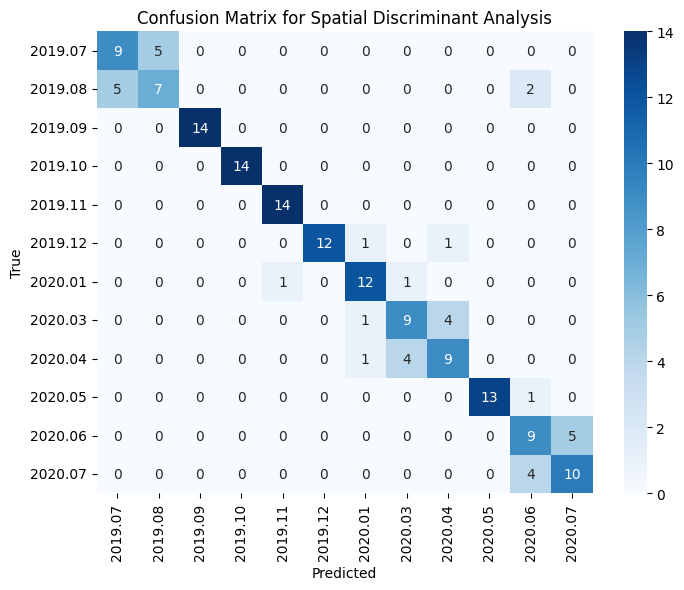

      Waktu  Accuracy  Precision    Recall  F1-Score
0   2019.07  0.642857        1.0  0.642857  0.782609
1   2019.08  0.500000        1.0  0.500000  0.666667
2   2019.09  1.000000        1.0  1.000000  1.000000
3   2019.10  1.000000        1.0  1.000000  1.000000
4   2019.11  1.000000        1.0  1.000000  1.000000
5   2019.12  0.857143        1.0  0.857143  0.923077
6   2020.01  0.857143        1.0  0.857143  0.923077
7   2020.03  0.642857        1.0  0.642857  0.782609
8   2020.04  0.642857        1.0  0.642857  0.782609
9   2020.05  0.928571        1.0  0.928571  0.962963
10  2020.06  0.642857        1.0  0.642857  0.782609
11  2020.07  0.714286        1.0  0.714286  0.833333


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

In [43]:
# 1. Load data dari file Word
from docx import Document
import pandas as pd

# Baca dokumen Word
doc = Document("/content/Data kualitas air.docx")

# Ekstrak semua tabel ke dalam list of lists
all_data = []
for table in doc.tables:
    for row in table.rows:
        all_data.append([cell.text.strip() for cell in row.cells])

# Atur baris pertama menjadi header
df = pd.DataFrame(all_data[1:], columns=all_data[0])

# Ganti nama kolom pertama menjadi 'Waktu' (asumsi kolom pertama adalah 'Waktu')
df = df.rename(columns={df.columns[0]: 'Waktu'})

# 3. Filter hanya kolom yang diperlukan (hapus kolom 'Waktu' dan 'NO.')
data = df.drop(columns=['Waktu', 'NO.'])  # Menghapus kolom 'Waktu' dan 'NO.'

# 3.5 Konversi kolom angka menjadi numerik
data.iloc[:, :] = data.apply(pd.to_numeric, errors='coerce')  # Mengonversi semua kolom menjadi numerik, jika tidak bisa maka NaN

# 2. Pisahkan fitur dan target
X = data  # Data fitur (seluruh kolom kecuali target)
y = df['Waktu']  # Kolom 'Waktu' sebagai label target lokasi

# 3. Standarisasi data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Membangun Model LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()

# 5. Latih model LDA
lda.fit(X_scaled, y)

# 6. Cross-Validation (5-fold CV)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lda, X_scaled, y, cv=5)
print(f"Cross-validation accuracy: {cv_scores.mean()}")

# 7. Confusion Matrix untuk evaluasi
from sklearn.metrics import confusion_matrix
y_pred = lda.predict(X_scaled)
conf_matrix = confusion_matrix(y, y_pred)

# 8. Tampilkan Confusion Matrix
print(f"Confusion Matrix:\n{conf_matrix}")

# 9. Visualisasi Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=lda.classes_, yticklabels=lda.classes_)
plt.title('Confusion Matrix for Spatial Discriminant Analysis')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 10. Evaluasi performa per waktu
location_evaluation = []

for waktu in df['Waktu'].unique():
    # Filter data berdasarkan waktu
    waktu_data = df[df['Waktu'] == waktu]
    X_waktu = waktu_data.drop(columns=['Waktu', 'NO.'])
    X_waktu = X_waktu.apply(pd.to_numeric, errors='coerce')  # pastikan numerik
    y_waktu = waktu_data['Waktu']

    # Standarisasi data
    X_waktu_scaled = scaler.transform(X_waktu)

    # Prediksi
    y_pred_waktu = lda.predict(X_waktu_scaled)

    # Evaluasi
    location_evaluation.append({
        'Waktu': waktu,
        'Accuracy': accuracy_score(y_waktu, y_pred_waktu),
        'Precision': precision_score(y_waktu, y_pred_waktu, average='weighted', labels=lda.classes_),
        'Recall': recall_score(y_waktu, y_pred_waktu, average='weighted', labels=lda.classes_),
        'F1-Score': f1_score(y_waktu, y_pred_waktu, average='weighted', labels=lda.classes_)
    })

# Tampilkan hasil evaluasi per waktu
waktu_evaluation_df = pd.DataFrame(location_evaluation)
print(waktu_evaluation_df)


Kenapa Akurasi LDA Turun Setelah PCA?
Informasi Penting Terpangkas:
PCA fokus pada variansi terbesar, bukan pada kelas target. Jadi, meski kita ambil 6 PC yang menjelaskan banyak variansi, bisa jadi komponen penting untuk membedakan kelas justru diabaikan.

LDA Sudah Optimal di Data Asli:
Karena LDA sendiri adalah metode supervised, ia tahu label dan belajar pola antar kelas. Sedangkan PCA unsupervised, tidak tahu mana variabel penting untuk klasifikasi.

Over-simplifikasi Struktur Data:
Bisa saja reduksi ke 6 PC terlalu sedikit. Mungkin informasi kelas tersebar di komponen ke-7, ke-8, dst.

**Metode LDA Sudah Optimal di Data Asli**

### **PCA (Principal Component Analysis)**

**Standarisasi Data**

In [44]:
# Standardisasi data numerik (df_numeric)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
scaled_data

array([[-0.83701226, -2.67636437,  1.13850716, ...,  1.61874176,
         1.49840587, -0.51203781],
       [-0.32329633,  0.18205403, -0.45623346, ..., -0.38088041,
         1.8917374 , -0.51203781],
       [-0.74360937, -0.35389942,  0.54047943, ...,  1.61874176,
         2.28506894,  0.21696518],
       ...,
       [ 0.28382249,  0.36070518, -0.35656217, ...,  0.28566031,
         0.31841125, -0.14753632],
       [-0.55680357, -0.88985287,  0.83949329, ...,  1.95201213,
        -0.07492029,  0.21696518],
       [ 0.14371815, -0.35389942,  0.54047943, ...,  0.28566031,
        -0.86158337, -0.51203781]])

**Uji Barlett**

**Hipotesis**

**H0** : Matriks korelasi sama dengan matriks identitas (tidak terdapat korelasi antar variabel).

**H1** : Matriks korelasi tidak sama dengan matriks identitas (terdapat korelasi antar variabel).

In [45]:
# Statistik Uji
chi_square_value, p_value = calculate_bartlett_sphericity(scaled_data)
print("================= Statistik Uji ================")
print(f"Chi-Square Bartlett \t: {chi_square_value:.2f}")
print(f"p-value \t\t: {p_value:.5f}")

# Keputusan berdasarkan p-value
print("============ Keputusan & Kesimpulan ============")
if p_value < 0.05:
    print("Keputusan  : Tolak H0. \nKesimpulan : Terdapat korelasi antar variabel.")
else:
    print(" Gagal tolak H0. Tidak terdapat korelasi antar variabel.")


================= Statistik Uji ================
Chi-Square Bartlett 	: 1306.42
p-value 		: 0.00000
============ Keputusan & Kesimpulan ============
Keputusan  : Tolak H0. 
Kesimpulan : Terdapat korelasi antar variabel.


Karena terdapat korelasi antar variabel, maka data layak dilanjutkan untuk PCA maupun analisis faktor.

**Uji KMO (Kaiser-Meyer-Olkin)**

Nilai statistik KMO berkisar antara 0 dan 1. Dalam praktik analisis faktor, apabila nilai KMO lebih dari 0.5, data dianggap layak untuk analisis faktor karena menunjukkan bahwa sampel cukup representatif. Selain itu, jika nilai KMO lebih besar dari 0.7, data dianggap baik dan cukup kuat untuk analisis faktor, yang menunjukkan bahwa analisis faktor akan memberikan hasil yang lebih efektif

**Hipotesis**

H0 : Data tidak layak dilanjutkan untuk PCA maupun analisis faktor.

H1 : Data layak dilanjutkan untuk PCA maupun analisis faktor.

In [46]:
# Nilai KMO
kmo_all, kmo_model = calculate_kmo(scaled_data)
print("========================= Nilai Statistik KMO =======================")
print(f"Nilai KMO: {kmo_model:.3f}")

# Keputusan berdasarkan KMO
print("======================== Keputusan & Kesimpulan =====================")
if kmo_model >= 0.50:
    print("Keputusan  : Tolak H0. \nKesimpulan : Data layak dilanjutkan untuk PCA maupun analisis faktor.")
else:
    print("Keputusan  : Gagal Tolak H0. \nKesimpulan Data tidak layak dilanjutkan untuk PCA maupun analisis faktor.")

========================= Nilai Statistik KMO =======================
Nilai KMO: 0.755
======================== Keputusan & Kesimpulan =====================
Keputusan  : Tolak H0. 
Kesimpulan : Data layak dilanjutkan untuk PCA maupun analisis faktor.


**Menentukan Jumlah Komponen Utama**

In [47]:
# Melakukan PCA
pca = PCA()
pca.fit(scaled_data)

PCA()

**Menentukan Jumlah Komponen Utama dengan Eigenvalues**

In [48]:
# Menghitung eigenvalues
eigenvalues = pca.explained_variance_

# Menampilkan eigenvalues
print("Eigenvalues:")
print(eigenvalues)

Eigenvalues:
[5.58573081 2.01036622 1.76487272 1.37673644 1.0966594  1.04920579
 0.99063517 0.8831942  0.79152122 0.67374208 0.55199258 0.43706279
 0.3833235  0.33181017 0.29967358 0.2473134  0.23392732 0.22901433
 0.17699074]


**Menentukan Jumlah Komponen Utama dengan Scree Plot**

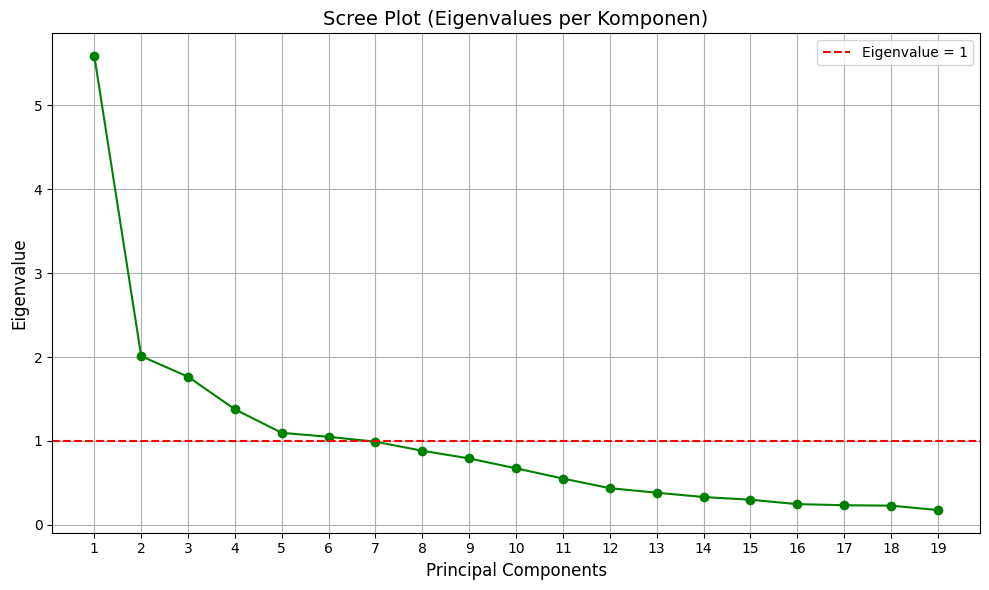

In [49]:
# Menampilkan Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='green')
plt.axhline(y=1, color='red', linestyle='--', label='Eigenvalue = 1')
plt.title('Scree Plot (Eigenvalues per Komponen)', fontsize=14)
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




**Menentukan Jumlah Komponen Utama dengan Cumulative Explained Variance**


Cumulative Explained Variance:
[0.29223592 0.39741485 0.48974998 0.56177849 0.61915384 0.6740465
 0.72587484 0.77208206 0.8134931  0.84874214 0.87762145 0.90048783
 0.92054266 0.9379024  0.95358081 0.96651983 0.97875851 0.99074015
 1.        ]


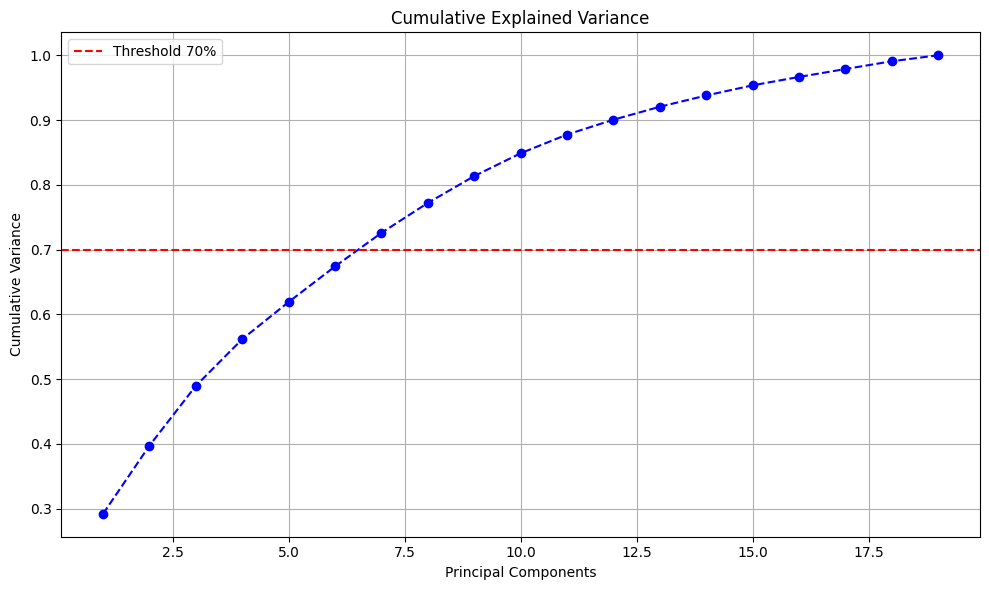

In [50]:
# Menghitung cumulative explained varianc
cumulative_variance = pca.explained_variance_ratio_.cumsum()

# Menampilkan cumulative explained variance
print("\nCumulative Explained Variance:")
print(cumulative_variance)

# Menampilkan plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='blue')
plt.title('Cumulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Variance')
plt.axhline(y=0.70, color='red', linestyle='--', label='Threshold 70%')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Explained Variance & Proportion of Variance**

In [64]:
import pandas as pd

# Mengambil explained variance untuk 6 komponen utama pertama
explained_variance = pca.explained_variance_[:6]

# Menghitung proporsi varians yang dijelaskan oleh masing-masing komponen utama
proportion_variance = pca.explained_variance_ratio_[:6]

# Membuat DataFrame untuk menampilkan hasilnya dalam tabel
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(6)],
    'Explained Variance': explained_variance,
    'Proportion of Variance': proportion_variance
})

# Menampilkan tabel dengan garis
variance_df.style.set_table_styles(
    [{'selector': 'thead th', 'props': [('border', '1px solid black')]},  # Border untuk header
     {'selector': 'tbody td', 'props': [('border', '1px solid black')]},  # Border untuk body
     {'selector': 'table', 'props': [('border-collapse', 'collapse')]}    # Collapse border
])

# Menampilkan tabel
variance_df

,PC,Explained Variance,Proportion of Variance
0,PC1,5.310527,0.351928
1,PC2,1.661076,0.110079
2,PC3,1.161112,0.076947
3,PC4,1.035064,0.068593
4,PC5,0.964667,0.063928
5,PC6,0.896031,0.059380


### **Analisis Faktor**

#### **Analisis Faktor Tanpa Reduksi**

**Uji Kelayakan Variabel dengan Nilai MSA pada Uji KMO**

Setelah data dinyatakan layak untuk PCA dan analisis faktor melalui Uji Bartlett dan KMO, dilakukan pemeriksaan nilai MSA tiap variabel dari Uji KMO. Variabel dengan nilai MSA > 0,50 dianggap layak untuk dianalisis lebih lanjut dalam analisis faktor.

In [65]:
# Hitung nilai KMO dan MSA
kmo_all, kmo_model = calculate_kmo(scaled_data)

# Buat tabel MSA dan keputusan kelayakan
msa_df = pd.DataFrame({
    'Variabel': df_numeric.columns,
    'Nilai MSA': kmo_all,
    'Kelayakan': ['Layak' if kmo >= 0.5 else 'Tidak Layak' for kmo in kmo_all]
})

# Tampilkan nilai KMO keseluruhan
print(f"Nilai KMO (keseluruhan): {kmo_model:.3f}")

# Tampilkan tabel MSA
print(msa_df)

Nilai KMO (keseluruhan): 0.755
   Variabel  Nilai MSA Kelayakan
0        PH   0.531521     Layak
1        DO   0.615273     Layak
2       COD   0.845093     Layak
3     NH3-N   0.703837     Layak
4        TP   0.872126     Layak
5     CODMn   0.842443     Layak
6         F   0.556333     Layak
7       Oil   0.680936     Layak
8      Cr6+   0.777592     Layak
9       LAS   0.560899     Layak
10       Cu   0.816584     Layak
11       Zn   0.721911     Layak
12       Cd   0.675133     Layak
13       As   0.766855     Layak
14       Hg   0.753791     Layak
15       CN   0.822131     Layak
16       VP   0.826538     Layak
17        S   0.780013     Layak
18       Se   0.550704     Layak


**Menentukan Jumlah Faktor**

Tabel Eigenvalue dan Variansi:
   Component  Eigenvalue  % of Variance  Cumulative %
0         F1    5.310527      35.192775     35.192775
1         F2    1.661076      11.007925     46.200701
2         F3    1.161112       7.694668     53.895368
3         F4    1.035064       6.859350     60.754718
4         F5    0.964667       6.392831     67.147549
5         F6    0.896031       5.937983     73.085532
6         F7    0.735478       4.873998     77.959531
7         F8    0.697152       4.620016     82.579547
8         F9    0.579321       3.839154     86.418701
9        F10    0.505775       3.351761     89.770462
10       F11    0.431895       2.862163     92.632625
11       F12    0.349268       2.314593     94.947218
12       F13    0.308734       2.045975     96.993194
13       F14    0.251344       1.665651     98.658845
14       F15    0.202378       1.341155    100.000000


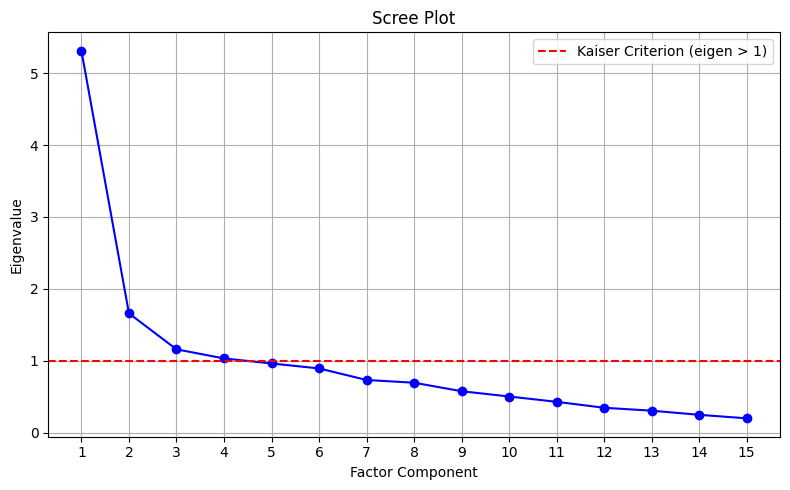

In [66]:
# Mendapatkan eigenvalues
eigenvalues = pca.explained_variance_

# Persentase variansi
explained_variance_ratio = pca.explained_variance_ratio_ * 100

# Persentase kumulatif
cumulative_variance = np.cumsum(explained_variance_ratio)

# Buat tabel hasil
eigen_table = pd.DataFrame({
    'Component': [f'F{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    '% of Variance': explained_variance_ratio,
    'Cumulative %': cumulative_variance
})

# Tampilkan tabel
print("Tabel Eigenvalue dan Variansi:")
print(eigen_table)

# Plot Scree Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor Component')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (eigen > 1)')
plt.xticks(range(1, len(eigenvalues)+1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Analisis Faktor dengan Rotasi Varimax**

In [69]:
# Install dulu jika belum terinstall
!pip install factor-analyzer

# Import library
from factor_analyzer import FactorAnalyzer

In [70]:
# Lakukan analisis faktor dengan rotasi Varimax
fa1 = FactorAnalyzer(n_factors=6, rotation='varimax')
fa1.fit(scaled_data
)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=6, rotation='varimax', rotation_kwargs={})

In [71]:
# Membuat DataFrame loadings
loadings_df = pd.DataFrame(fa1.loadings_,
                           index=df_numeric.columns,
                           columns=['VF1', 'VF2', 'VF3', 'VF4', 'VF5', 'VF6'])

# Menghitung eigenvalue, % variance, cumulative %
ev = fa1.get_eigenvalues()[0][:6]
percent_var = ev / len(df_numeric.columns) * 100
cum_var = np.cumsum(percent_var)

# Menambahkan Eigenvalue, % Variance, dan Cumulative %
summary_df = pd.DataFrame({
    'VF1': [ev[0], percent_var[0], cum_var[0]],
    'VF2': [ev[1], percent_var[1], cum_var[1]],
    'VF3': [ev[2], percent_var[2], cum_var[2]],
    'VF4': [ev[3], percent_var[3], cum_var[3]],
    'VF5': [ev[4], percent_var[4], cum_var[4]],
    'VF6': [ev[5], percent_var[5], cum_var[5]]
}, index=['Eigenvalue', '% Variance', 'Cumulative %'])

# Gabungkan hasil loading dan summary
combined_df = pd.concat([loadings_df, summary_df])

# Tampilkan hasil
print("Factor Loadings dan Variance Explained dengan Rotasi Varimax:")
print(combined_df.round(3))


Factor Loadings dan Variance Explained dengan Rotasi Varimax:
                 VF1     VF2     VF3     VF4     VF5     VF6
PH            -0.208   0.008   0.082  -0.062  -0.075   0.554
DO            -0.279  -0.111   0.022   0.156  -0.174  -0.033
COD            0.328   0.487   0.232   0.185   0.346  -0.019
NH3-N          0.450   0.222   0.223  -0.325  -0.291  -0.029
TP             0.610   0.371   0.176  -0.004  -0.035  -0.112
CODMn          0.238   0.739   0.196  -0.007   0.031  -0.131
F             -0.005   0.183   0.112   0.978   0.109   0.042
Oil            0.210   0.398   0.033   0.313   0.122   0.240
Cr6+           0.180   0.658  -0.001   0.143   0.336  -0.120
LAS            0.385  -0.040   0.115   0.153   0.015   0.697
Cu             0.786   0.105   0.059   0.192   0.108  -0.074
Zn             0.134   0.232   0.123  -0.036  -0.021  -0.325
Cd             0.017   0.147   0.103   0.083   0.683  -0.035
As             0.320   0.212   0.426   0.195   0.352  -0.006
Hg             0.515   

**Pengelompokan Faktor**

In [72]:
# Threshold untuk menentukan faktor signifikan
threshold = 0.5

# Menentukan pengelompokan variabel berdasarkan nilai loading > threshold
grouped_factors1 = {'VF1': [], 'VF2': [], 'VF3': [], 'VF4': [], 'VF5': [], 'VF6': []}

# Looping untuk mengelompokkan variabel berdasarkan faktor dengan loading > threshold
for var in loadings_df.index:  # Loop untuk baris (variabel)
    for factor in loadings_df.columns:  # Loop untuk kolom (faktor)
        if abs(loadings_df.loc[var, factor]) > threshold:
            grouped_factors1[factor].append(var)

# Menampilkan hasil pengelompokan
grouped_factors_df1 = pd.DataFrame.from_dict(grouped_factors1, orient='index').T

# Mengganti None dengan string kosong
grouped_factors_df1 = grouped_factors_df1.fillna('-')

# Menampilkan hasil pengelompokan setelah diubah
print("Hasil Pengelompokan Faktor")
print(grouped_factors_df1)

Hasil Pengelompokan Faktor
  VF1    VF2 VF3 VF4 VF5  VF6
0  TP  CODMn  Se   F  Cd   PH
1  Cu   Cr6+   -   -   -  LAS
2  Hg      -   -   -   -    -
3  CN      -   -   -   -    -
4  VP      -   -   -   -    -
5   S      -   -   -   -    -


#### **Analisis Faktor Dengan Reduksi**

**Uji Kelayakan Variabel dengan Nilai MSA pada Uji KMO**

Setelah data dinyatakan layak untuk PCA dan analisis faktor melalui Uji Bartlett dan KMO, dilakukan pemeriksaan nilai MSA tiap variabel dari Uji KMO. Variabel dengan nilai MSA > 0,60 dianggap cukup baik untuk dianalisis lebih lanjut dalam analisis faktor.

In [73]:
# Hitung nilai KMO dan MSA
kmo_all, kmo_model = calculate_kmo(scaled_data)

# Buat tabel MSA dan keputusan kelayakan
msa = pd.DataFrame({
    'Variabel': df_numeric.columns,
    'Nilai MSA': kmo_all,
    'Kelayakan': ['Layak' if kmo >= 0.6 else 'Tidak Layak' for kmo in kmo_all]
})

# Tampilkan nilai KMO keseluruhan
print(f"Nilai KMO (keseluruhan): {kmo_model:.3f}")

# Tampilkan tabel MSA
print(msa)

Nilai KMO (keseluruhan): 0.755
   Variabel  Nilai MSA    Kelayakan
0        PH   0.531521  Tidak Layak
1        DO   0.615273        Layak
2       COD   0.845093        Layak
3     NH3-N   0.703837        Layak
4        TP   0.872126        Layak
5     CODMn   0.842443        Layak
6         F   0.556333  Tidak Layak
7       Oil   0.680936        Layak
8      Cr6+   0.777592        Layak
9       LAS   0.560899  Tidak Layak
10       Cu   0.816584        Layak
11       Zn   0.721911        Layak
12       Cd   0.675133        Layak
13       As   0.766855        Layak
14       Hg   0.753791        Layak
15       CN   0.822131        Layak
16       VP   0.826538        Layak
17        S   0.780013        Layak
18       Se   0.550704  Tidak Layak


**Mereduksi Variabel**

In [74]:
# Fungsi untuk menghitung KMO dan MSA
def calculate_kmo_and_msa(df):
    # Standardisasi data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df)

    # Menghitung KMO keseluruhan dan MSA untuk setiap variabel
    kmo_all, kmo_model = calculate_kmo(scaled_data)  # calculate_kmo sudah ada di factor_analyzer

    return kmo_all, kmo_model

# Fungsi untuk mereduksi variabel berdasarkan MSA
def reduce_variables_by_msa(df):
    # Menghitung KMO dan MSA pertama kali
    kmo_all, kmo_model = calculate_kmo_and_msa(df)

    # Buat tabel MSA
    msa = pd.DataFrame({
        'Variabel': df.columns,
        'Nilai MSA': kmo_all,
        'Kelayakan': ['Cukup Baik' if kmo >= 0.6 else 'Tidak Cukup Baik' for kmo in kmo_all]
    })

    # Menampilkan nilai KMO keseluruhan sebelum reduksi
    print(f"Nilai KMO (keseluruhan sebelum reduksi): {kmo_model:.3f}")

    # Loop untuk mengeluarkan variabel dengan MSA terkecil
    while (msa['Nilai MSA'] < 0.6).any():  # Selama ada variabel dengan MSA < 0.6
        # Menemukan variabel dengan MSA terkecil
        min_msa_idx = msa['Nilai MSA'].idxmin()
        min_msa_var = msa.loc[min_msa_idx, 'Variabel']

        # Mengeluarkan variabel tersebut dari data
        df = df.drop(columns=[min_msa_var])

        # Menghitung ulang MSA setelah pengeluaran
        kmo_all, kmo_model = calculate_kmo_and_msa(df)

        # Update tabel MSA
        msa = pd.DataFrame({
            'Variabel': df.columns,
            'Nilai MSA': kmo_all,
            'Kelayakan': ['Cukup Baik' if kmo >= 0.6 else 'Tidak Cukup Baik' for kmo in kmo_all]
        })

        # Tampilkan nilai KMO keseluruhan setelah pengeluaran variabel
        print(f"\nVariabel '{min_msa_var}' dikeluarkan. \nNilai KMO keseluruhan setelah reduksi: {kmo_model:.3f}")
        print(msa)

    return msa

# Contoh pemanggilan fungsi dengan df_numeric
reduced_msa = reduce_variables_by_msa(df_numeric)

# Tampilkan tabel MSA setelah pengeluaran variabel
print("\nTabel MSA setelah reduksi:")
print(reduced_msa)

Nilai KMO (keseluruhan sebelum reduksi): 0.755

Variabel 'PH' dikeluarkan. 
Nilai KMO keseluruhan setelah reduksi: 0.762
   Variabel  Nilai MSA         Kelayakan
0        DO   0.666836        Cukup Baik
1       COD   0.842001        Cukup Baik
2     NH3-N   0.707134        Cukup Baik
3        TP   0.879832        Cukup Baik
4     CODMn   0.840762        Cukup Baik
5         F   0.566282  Tidak Cukup Baik
6       Oil   0.671898        Cukup Baik
7      Cr6+   0.777573        Cukup Baik
8       LAS   0.597762  Tidak Cukup Baik
9        Cu   0.813864        Cukup Baik
10       Zn   0.679723        Cukup Baik
11       Cd   0.670468        Cukup Baik
12       As   0.770408        Cukup Baik
13       Hg   0.734287        Cukup Baik
14       CN   0.826482        Cukup Baik
15       VP   0.822635        Cukup Baik
16        S   0.782453        Cukup Baik
17       Se   0.543336  Tidak Cukup Baik

Variabel 'Se' dikeluarkan. 
Nilai KMO keseluruhan setelah reduksi: 0.779
   Variabel  Nilai MSA    

**Menentukan Jumlah Faktor**

Tabel Eigenvalue dan Cumulative Variance Explained:
   Factor Component  Eigenvalue  % of Variance  Cumulative %
0                F1    5.310527      35.192775     35.192775
1                F2    1.661076      11.007925     46.200701
2                F3    1.161112       7.694668     53.895368
3                F4    1.035064       6.859350     60.754718
4                F5    0.964667       6.392831     67.147549
5                F6    0.896031       5.937983     73.085532
6                F7    0.735478       4.873998     77.959531
7                F8    0.697152       4.620016     82.579547
8                F9    0.579321       3.839154     86.418701
9               F10    0.505775       3.351761     89.770462
10              F11    0.431895       2.862163     92.632625
11              F12    0.349268       2.314593     94.947218
12              F13    0.308734       2.045975     96.993194
13              F14    0.251344       1.665651     98.658845
14              F15    0.202378  

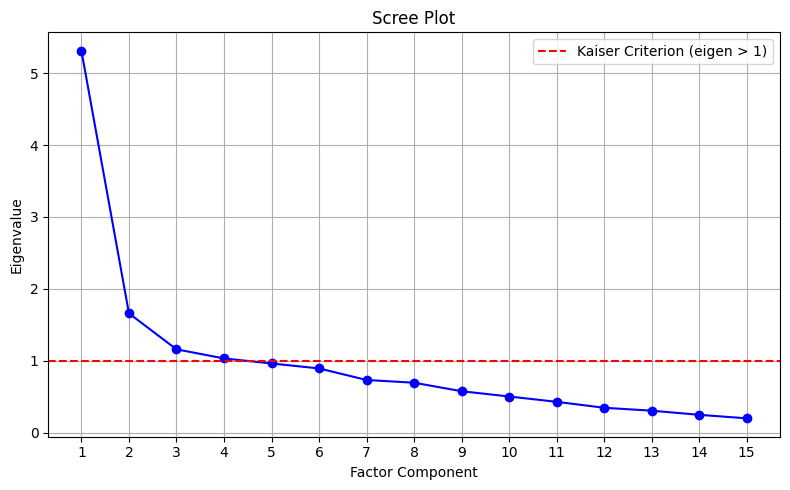

In [76]:
# Mengambil nama-nama variabel yang tersisa setelah direduksi
selected_variables = reduced_msa['Variabel']

# Membuat df_reduced dengan variabel yang terpilih
df_reduced = df[selected_variables]

# Standarisasi data
scaled_df_reduced= StandardScaler().fit_transform(df_reduced)

# Gunakan PCA untuk analisis faktor
pca = PCA()
pca.fit(scaled_df_reduced)

# Mendapatkan eigenvalues
eigenvalues = pca.explained_variance_

# Persentase variansi
explained_variance_ratio = pca.explained_variance_ratio_ * 100

# Persentase kumulatif
cumulative_variance = np.cumsum(explained_variance_ratio)

# Buat tabel hasil
eigen_table = pd.DataFrame({
    'Factor Component': [f'F{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    '% of Variance': explained_variance_ratio,
    'Cumulative %': cumulative_variance
})

# Tampilkan tabel
print("Tabel Eigenvalue dan Cumulative Variance Explained:")
print(eigen_table)

# Plot Scree Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor Component')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (eigen > 1)')
plt.xticks(range(1, len(eigenvalues)+1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Analisis Faktor dengan Rotasi Varimax**

In [77]:
# Melakukan analisis faktor dengan rotasi Varimax
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(scaled_df_reduced)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=4, rotation='varimax', rotation_kwargs={})

In [78]:
# Menampilkan tabel loadings faktor setelah rotasi Varimax
loadings = pd.DataFrame(fa.loadings_,
                        index=df_reduced.columns,
                        columns=['VF1', 'VF2', 'VF3', 'VF4'])

# Menghitung eigenvalue, % variance, cumulative %
ev = fa.get_eigenvalues()[0][:4]
percent_var = ev / len(df_reduced.columns) * 100
cum_var = np.cumsum(percent_var)

# Menambahkan Eigenvalue, % Variance, dan Cumulative %
summary = pd.DataFrame({
    'VF1': [ev[0], percent_var[0], cum_var[0]],
    'VF2': [ev[1], percent_var[1], cum_var[1]],
    'VF3': [ev[2], percent_var[2], cum_var[2]],
    'VF4': [ev[3], percent_var[3], cum_var[3]]
}, index=['Eigenvalue', '% Variance', 'Cumulative %'])

# Menggabungkan loading + summary
combined = pd.concat([loadings, summary])

# Menampilkan tabel hasil
print("Factor Loadings dan Variance Explained dengan Rotasi Varimax :")
print(combined.round(3))

Factor Loadings dan Variance Explained dengan Rotasi Varimax :
                 VF1     VF2     VF3     VF4
DO            -0.283  -0.118  -0.047   0.003
COD            0.348   0.554   0.321  -0.084
NH3-N          0.216   0.210   0.072   0.569
TP             0.568   0.406  -0.007   0.318
CODMn          0.221   0.710   0.108   0.181
Oil            0.187   0.338   0.237  -0.014
Cr6+           0.211   0.758   0.152  -0.163
Cu             0.644   0.209   0.186   0.205
Zn             0.123   0.253   0.025   0.130
Cd             0.225   0.269   0.196  -0.517
As             0.216   0.239   0.946  -0.014
Hg             0.445   0.159   0.233   0.079
CN             0.728   0.216   0.156  -0.210
VP             0.698   0.407   0.033  -0.012
S              0.656   0.095   0.207   0.459
Eigenvalue     5.279   1.651   1.154   1.029
% Variance    35.193  11.008   7.695   6.859
Cumulative %  35.193  46.201  53.895  60.755


**Pengelompokan Faktor**

In [79]:
# Threshold untuk menentukan faktor signifikan
threshold = 0.5

# Menentukan pengelompokan variabel berdasarkan nilai loading > threshold
grouped_factors = {'VF1': [], 'VF2': [], 'VF3': [], 'VF4': []}

# Looping untuk mengelompokkan variabel berdasarkan faktor dengan loading > threshold
for var in loadings.index:  # Loop untuk baris (variabel)
    for factor in loadings.columns:  # Loop untuk kolom (faktor)
        if abs(loadings.loc[var, factor]) > threshold:
            grouped_factors[factor].append(var)

# Menampilkan hasil pengelompokan
grouped_factors_df = pd.DataFrame.from_dict(grouped_factors, orient='index').T

# Mengganti None dengan string kosong
grouped_factors_df = grouped_factors_df.fillna('-')

# Menampilkan hasil pengelompokan setelah diubah
print("Hasil Pengelompokan Faktor")
print(grouped_factors_df)

Hasil Pengelompokan Faktor
  VF1    VF2 VF3    VF4
0  TP    COD  As  NH3-N
1  Cu  CODMn   -     Cd
2  CN   Cr6+   -      -
3  VP      -   -      -
4   S      -   -      -


### **Analisis Cluster Pada Data Hasil Analisis Faktor**

#### **Analisis Cluster Spasial**

In [80]:
whos

Variable                        Type                          Data/Info
-----------------------------------------------------------------------
Document                        function                      <function Document at 0x7cb6861684a0>
FactorAnalysis                  type                          <class 'sklearn.decomposi<...>analysis.FactorAnalysis'>
FactorAnalyzer                  type                          <class 'factor_analyzer.f<...>analyzer.FactorAnalyzer'>
H                               float64                       1.1191388084171412
LinearDiscriminantAnalysis      type                          <class 'sklearn.discrimin<...>earDiscriminantAnalysis'>
PCA                             ABCMeta                       <class 'sklearn.decomposition._pca.PCA'>
RFE                             ABCMeta                       <class 'sklearn.feature_selection._rfe.RFE'>
StandardScaler                  type                          <class 'sklearn.preproces<...>ng._data.StandardSc

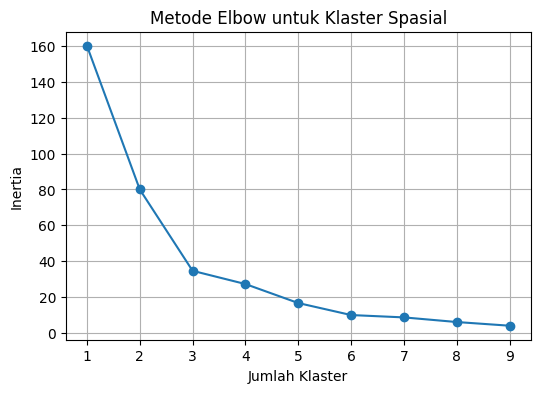

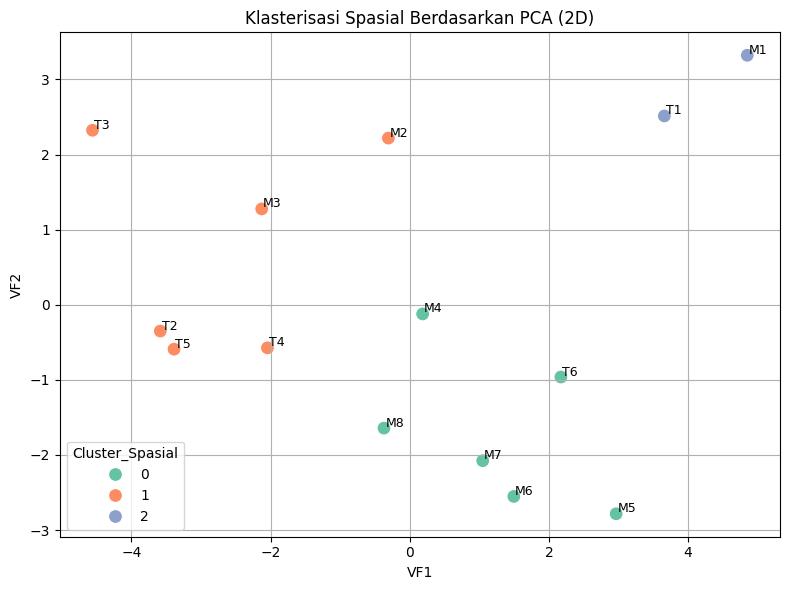

,Lokasi,Cluster_Spasial
0,M1,2
1,M2,1
2,M3,1
3,M4,0
4,M5,0
5,M6,0
6,M7,0
7,M8,0
8,T1,2
9,T2,1


In [81]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Siapkan nama lokasi sesuai urutan data ---
lokasi_list = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']

# --- 2. Ubah scaled_data_location jadi DataFrame ---
df_loc_raw = pd.DataFrame(scaled_data_location, index=lokasi_list)

# --- 3. Reduksi dimensi dengan PCA (VF1 dan VF2) ---
pca = PCA(n_components=2)
faktor_2d = pca.fit_transform(scaled_data_location)
df_loc = pd.DataFrame(faktor_2d, columns=['VF1', 'VF2'])
df_loc['Lokasi'] = lokasi_list

# --- 4. Menentukan jumlah klaster optimal (Elbow Method) ---
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_loc[['VF1', 'VF2']])
    inertia.append(km.inertia_)

# Plot Elbow
plt.figure(figsize=(6, 4))
plt.plot(K, inertia, marker='o')
plt.title('Metode Elbow untuk Klaster Spasial')
plt.xlabel('Jumlah Klaster')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# --- 5. KMeans dengan jumlah klaster optimal (misal 3) ---
k_opt = 3  # ganti kalau Elbow menunjukkan jumlah lain
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df_loc['Cluster_Spasial'] = kmeans.fit_predict(df_loc[['VF1', 'VF2']])

# --- 6. Visualisasi Hasil Klaster Spasial ---
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_loc, x='VF1', y='VF2', hue='Cluster_Spasial', palette='Set2', s=100)
for i, row in df_loc.iterrows():
    plt.text(row['VF1']+0.02, row['VF2']+0.02, row['Lokasi'], fontsize=9)
plt.title('Klasterisasi Spasial Berdasarkan PCA (2D)')
plt.xlabel('VF1')
plt.ylabel('VF2')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 7. Tampilkan hasil klaster
df_loc[['Lokasi', 'Cluster_Spasial']]


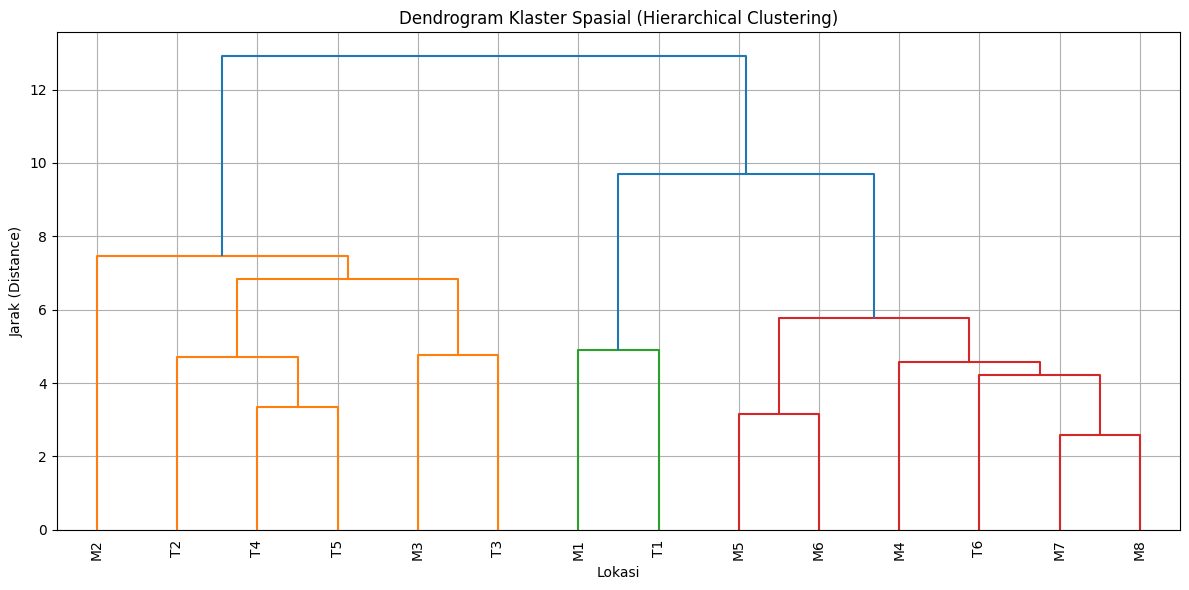

In [87]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

# Daftar nama lokasi (harus urut sesuai scaled_data_location)
lokasi_list = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']

# linked_location sudah tersedia dari linkage()
# Misalnya sebelumnya kamu punya: linked_location = linkage(scaled_data_location, method='ward')

# Buat dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked_location, labels=lokasi_list, leaf_rotation=90, leaf_font_size=10, color_threshold=None)
plt.title('Dendrogram Klaster Spasial (Hierarchical Clustering)')
plt.xlabel('Lokasi')
plt.ylabel('Jarak (Distance)')
plt.tight_layout()
plt.grid(True)
plt.show()


#### **Analisis Cluster Temporal**

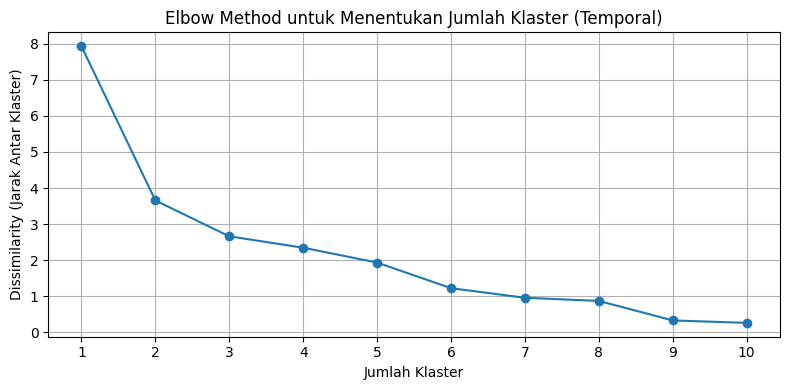

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage

# 1. Gunakan data temporal 4 faktor
faktor_temporal = ['TP', 'Cu', 'CN', 'VP']
df_temporal_4faktor = df_temporal[faktor_temporal].copy()

# 2. Hitung linkage (ward)
Z = linkage(df_temporal_4faktor, method='ward')

# 3. Hitung jarak antar klaster (dissimilarities)
last = Z[-10:, 2]  # Ambil 10 jarak terakhir
num_clusters = range(1, len(last) + 1)

# 4. Plot Elbow
plt.figure(figsize=(8, 4))
plt.plot(num_clusters, last[::-1], marker='o')
plt.title('Elbow Method untuk Menentukan Jumlah Klaster (Temporal)')
plt.xlabel('Jumlah Klaster')
plt.ylabel('Dissimilarity (Jarak Antar Klaster)')
plt.xticks(num_clusters)
plt.grid(True)
plt.tight_layout()
plt.show()


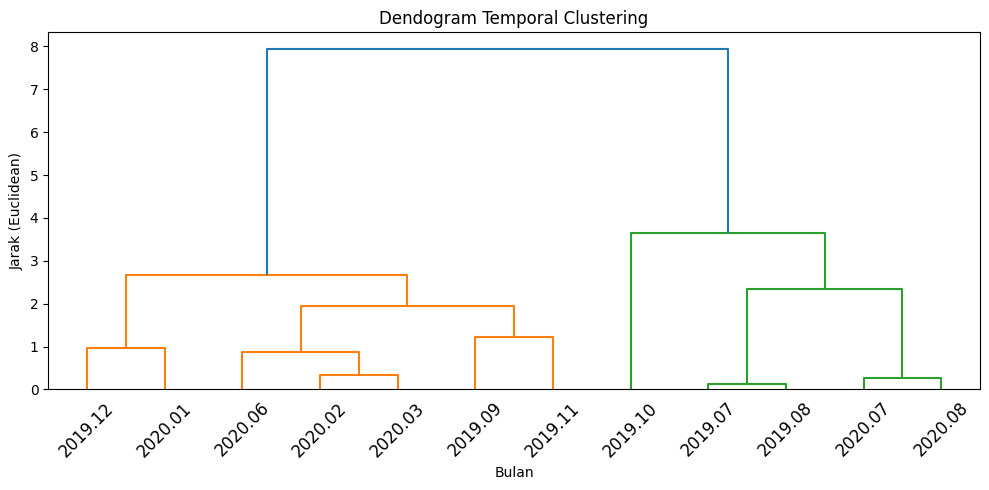

      Bulan  Cluster
0   2019.07        2
1   2019.08        2
2   2019.09        1
3   2019.10        2
4   2019.11        1
5   2019.12        1
6   2020.01        1
7   2020.02        1
8   2020.03        1
9   2020.06        1
10  2020.07        2
11  2020.08        2


In [91]:
import pandas as pd
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# 1. Pilih 4 faktor yang dianggap paling signifikan (contoh)
# (Silakan sesuaikan 4 ini dengan hasil PCA atau faktor analisismu jika tersedia)
faktor_utama = ['TP', 'Cu', 'CN', 'VP']

# 2. Ambil data temporal dari 4 faktor tersebut
df_temporal_4faktor = df_temporal[faktor_utama].copy()

# 3. Buat dendogram
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(df_temporal_4faktor, method='ward'), labels=df_temporal_4faktor.index)
plt.title('Dendogram Temporal Clustering')
plt.xlabel('Bulan')
plt.ylabel('Jarak (Euclidean)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Ambil cluster (2 klaster)
clusters = fcluster(sch.linkage(df_temporal_4faktor, method='ward'), t=2, criterion='maxclust')

# 5. Gabungkan hasil cluster dengan label bulan
hasil_cluster_temporal = pd.DataFrame({
    'Bulan': df_temporal_4faktor.index,
    'Cluster': clusters
})

# 6. Tampilkan hasil
print(hasil_cluster_temporal)
